 # EXPLORATORY DATA ANALYSIS TO PREDICT INCOME

# Overview del dataset e scopo
Adult or "Census Income"

Visitabile a: https://archive.ics.uci.edu/dataset/2/adult

Questo dataset contiene informazioni anagrafiche, lavorative ed economiche estratte dal database del censimento statunitense del 1994, con l’obiettivo di studiare i fattori associati al reddito individuale.

L’obiettivo del progetto è analizzare il dataset utilizzando strumenti di data analytics ed exploratory data analysis per comprenderne struttura, distribuzioni, relazioni tra variabili e pattern rilevanti.

Successivamente, il dataset verrà processato e trasformato per adattarlo a un task di classificazione binaria, con l’obiettivo di predire se il reddito annuale di un individuo supera o meno i 50.000 dollari:
- `<=50K`
- `>50K`

Il dataset è stato scelto  perché combina feature socio-demografiche e lavorative, consentendo di studiare  fattori quali istruzione, età, occupazione e ore lavorative influenzino il livello di reddito.

Breve overview delle feature:
- Age:                 Integer        (età dell’individuo)
- Workclass:           Categorical    (tipologia lavorativa)
- fnlwgt:              Integer        (peso statistico del censimento)
- Education:           Categorical    (titolo di studio)
- Education-num:       Integer        (versione numerica del livello di istruzione)
- Marital-status:      Categorical    (stato civile)
- Occupation:          Categorical    (occupazione)
- Relationship:        Categorical    (relazione familiare)
- Race:                Categorical    (gruppo etnico)
- Sex:                 Binary         (sesso biologico)
- Capital-gain:        Integer        (guadagni derivanti da investimenti o vendita di asset finanziari/immobiliari)
- Capital-loss:        Integer        (perdite derivanti da investimenti o vendita di asset finanziari/immobiliari)
- Hours-per-week:      Integer        (ore lavorate a settimana)
- Native-country:      Categorical    (paese di origine)
- Income:              Binary Target  (<=50K / >50K)


# Workflow

Per chiarezza scrivo gli step seguiti nel notebook, (ispirati dall'esempio fornito):
- load del dataste
- controlli iniziali sulla qualità e integrità del dataset
- studio delle variabili numeriche e categoriche
- analisi delle distribuzioni tramite misure di centralità 
- EDA per studiare e interpretare i dati
- studio delle correlazioni
- gestione dei missing data
- PCA
- detection degli outlier
- preparare il dataset da un task di classificazione
- valutare l'efficacia del modello predittivo

# Load del dataset
Zip scaricato al seguente link: https://archive.ics.uci.edu/dataset/2/adult

Per riproducibilità specifico che i due file erano "adult.data" e "adult.test" che ho unito in "adult.csv"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
 
df = pd.read_csv('adult.csv')
df.columns = df.columns.str.strip()
print(df.columns)
df.head()


Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,39,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
4,50,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K


# Controlli iniziali sulla qualità e integrità del dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48845 entries, 0 to 48844
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48845 non-null  int64  
 1   workclass       48845 non-null  str    
 2   fnlwgt          48844 non-null  float64
 3   education       48844 non-null  str    
 4   education-num   48844 non-null  float64
 5   marital-status  48844 non-null  str    
 6   occupation      48844 non-null  str    
 7   relationship    48844 non-null  str    
 8   race            48844 non-null  str    
 9   sex             48844 non-null  str    
 10  capital-gain    48844 non-null  float64
 11  capital-loss    48844 non-null  float64
 12  hours-per-week  48844 non-null  float64
 13  native-country  48844 non-null  str    
 14  income          48844 non-null  str    
dtypes: float64(5), int64(1), str(9)
memory usage: 5.6 MB


Dall'output si vede che sono presenti missing values.
In realtà come si vedrà nelle analisi successive la maggior parte dei missing data sono encodati come '?'.

In [4]:
df.isna().sum()    # per confermare la presenza di valori nulli    

age               0
workclass         0
fnlwgt            1
education         1
education-num     1
marital-status    1
occupation        1
relationship      1
race              1
sex               1
capital-gain      1
capital-loss      1
hours-per-week    1
native-country    1
income            1
dtype: int64

In [5]:
# Per avere una breve descrizione dei valori numerici 
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48845.000000,4.884400e+04,48844.000000,48844.000000,48844.000000,48844.000000
mean,38.643812,1.896597e+05,10.078208,1079.067951,87.498731,40.421812
std,13.710186,1.056042e+05,2.570988,7451.869732,402.996690,12.391812
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175472e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781410e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376340e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


Alcuni valori sembrano anomali come 99 ore settimanali o 99.999 dollari ottenuti in asset finanziari, ma visto che potrebbero comunque essere accettabili li andiamo ad analizzare prendendo l'intera osservazione

In [6]:
# Tuple con capital gain maggiore di 90.000
high_capital_gain = df[df["capital-gain"] > 90000]    
print("Osservazioni con capital-gain > 90000:")
high_capital_gain

Osservazioni con capital-gain > 90000:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
1249,54,Self-emp-inc,166459.0,Prof-school,15.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999.0,0.0,60.0,United-States,>50K
1371,52,Private,152234.0,HS-grad,9.0,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,99999.0,0.0,40.0,Japan,>50K
1485,53,Self-emp-inc,263925.0,HS-grad,9.0,Married-civ-spouse,Sales,Husband,White,Male,99999.0,0.0,40.0,United-States,>50K
1531,52,Private,118025.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999.0,0.0,50.0,United-States,>50K
1619,46,Private,370119.0,Prof-school,15.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999.0,0.0,60.0,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47742,32,Self-emp-inc,225053.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999.0,0.0,60.0,United-States,>50K.
48585,61,Self-emp-not-inc,151369.0,Masters,14.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999.0,0.0,30.0,United-States,>50K.
48594,36,Private,224566.0,Bachelors,13.0,Never-married,Prof-specialty,Not-in-family,White,Male,99999.0,0.0,45.0,United-States,>50K.
48601,42,Private,32878.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999.0,0.0,42.0,United-States,>50K.


In [7]:
# Raggruppa per occupazione e income chi ha capital-gain > 90000
high_capital_gain.groupby(["occupation", "income"]).agg(
    conteggio=("occupation", "count")
).sort_values("conteggio", ascending=False)

conteggio
occupation        income           
Prof-specialty    >50K           67
Exec-managerial   >50K           42
Prof-specialty    >50K.          34
Exec-managerial   >50K.          25
Sales             >50K           25
                  >50K.           9
Craft-repair      >50K.           8
                  >50K            8
Adm-clerical      >50K            6
?                 >50K            4
Farming-fishing   >50K.           3
Adm-clerical      >50K.           2
Other-service     >50K            2
?                 >50K.           1
Other-service     >50K.           1
Machine-op-inspct >50K            1
Handlers-cleaners >50K.           1
                  >50K            1
Protective-serv   >50K.           1
                  >50K            1
Tech-support      >50K            1
Transport-moving  >50K            1

Dall'output è chiaro che tutte le persone con alto capital gain sono impreditori, lavoratori privati, manager, tutti con un income > 50k per cui il dato sembra ragionevole, per fare un check aggiuntivo controllo se esiste un individuo con income < 50k e con capital gain alto (>90k).

In [8]:
df_filtrato = df[(df["capital-gain"] > 90000) & (df["income"] == "<=50K")]
print(f"\nTuple con capital-gain=99999 MA income<=50K: {len(df_filtrato)}")
print(df_filtrato[["age", "workclass", "occupation", "hours-per-week", "income"]])


Tuple con capital-gain=99999 MA income<=50K: 0
Empty DataFrame
Columns: [age, workclass, occupation, hours-per-week, income]
Index: []


L'output suggerisce che i valori di capital-gain siano legittimi, in quanto nessuno con income <50k abbia un alto capital gain.

Analizziamo ora similmente coloro che lavorano >90h a settimana.

In [9]:
# Tuple con ore settimanali > 90
high_hours = df[df["hours-per-week"] > 90]
print(f"Osservazioni con hours-per-week > 90: {len(high_hours)}")
high_hours

Osservazioni con hours-per-week > 90: 171


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
275,50,Self-emp-not-inc,30653.0,Masters,14.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,2407.0,0.0,98.0,United-States,<=50K
938,37,Private,176900.0,HS-grad,9.0,Married-civ-spouse,Craft-repair,Husband,White,Male,0.0,0.0,99.0,United-States,>50K
1175,25,Private,404616.0,Masters,14.0,Married-civ-spouse,Farming-fishing,Not-in-family,White,Male,0.0,0.0,99.0,United-States,>50K
1890,55,Self-emp-not-inc,184425.0,Some-college,10.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,99.0,United-States,>50K
2923,63,Self-emp-not-inc,26904.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,98.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47110,32,State-gov,246282.0,Doctorate,16.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,2961.0,0.0,99.0,?,<=50K.
47379,49,?,111282.0,7th-8th,4.0,Married-civ-spouse,?,Husband,White,Male,4386.0,0.0,99.0,United-States,>50K.
47763,48,Private,250736.0,HS-grad,9.0,Married-civ-spouse,Transport-moving,Husband,Black,Male,0.0,0.0,99.0,United-States,<=50K.
48133,43,Self-emp-inc,314739.0,Some-college,10.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,92.0,United-States,>50K.


In [10]:
# Raggruppa per occupazione chi lavora più di 90 ore
high_hours.groupby("occupation").size().sort_values(ascending=False)

occupation
Farming-fishing      33
Prof-specialty       26
Exec-managerial      22
Transport-moving     21
Other-service        16
Craft-repair         12
?                    11
Sales                11
Protective-serv       8
Priv-house-serv       4
Handlers-cleaners     2
Adm-clerical          2
Tech-support          2
Machine-op-inspct     1
dtype: int64

Sembra ragionevole che coloro che hanno un alto numero di ore settimanali siano lavori come "farming / fishin", manager e trasporti, motivo per cui non li considero in questa prima analisi come outlier.

# Visualizzazione iniziali delle distribuzioni 

Lo scopo è quello di farsi una idea sull'organizzazione del dataset, capire ogni variabile come è appunto distribuita.

La distribuzione ci dirà anche quale metrica di centralità è più adatta, e eventualmente se è sensato effettuare delle trasformazioni.



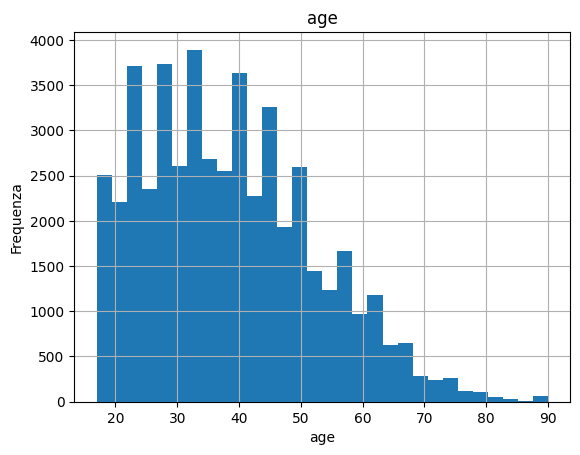

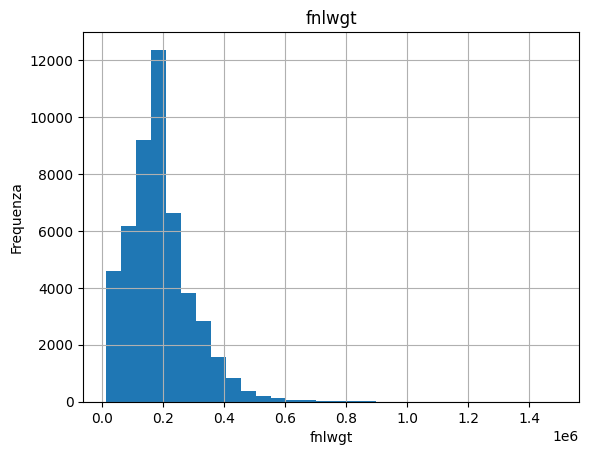

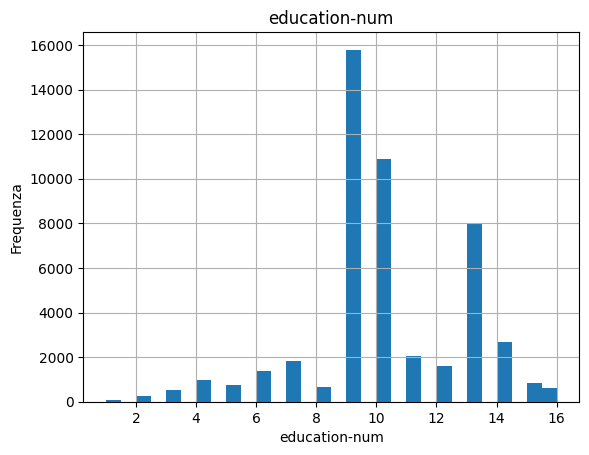

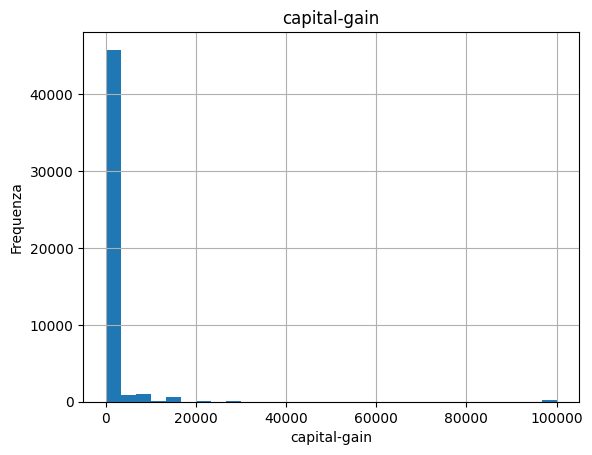

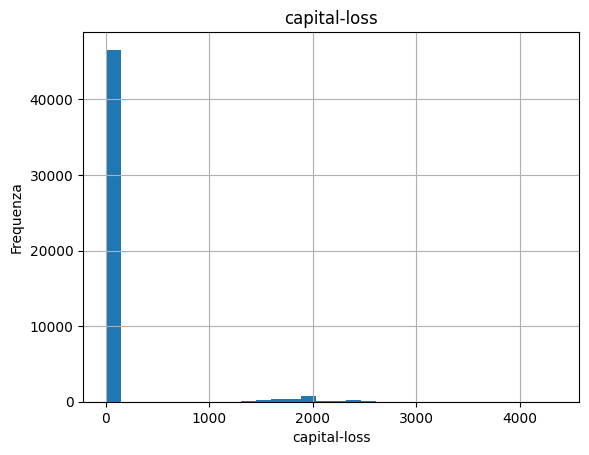

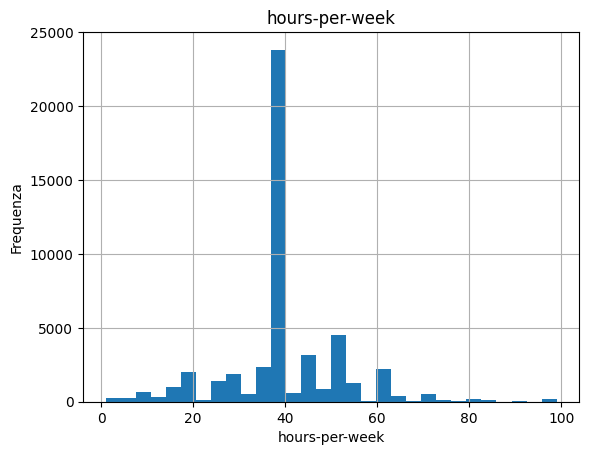

In [11]:

for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        df[column].hist(bins=30)
        plt.title(column)
        plt.xlabel(column)
        plt.ylabel("Frequenza")
        plt.show()

## Misure di centralità e dispersione

I plot delle distribuzioni mostrano che quasi tutte le variabili numeriche presentano 
distribuzioni asimmetriche o con code  in una direzione, per questo motivo uso la mediana e l'IQR come misure essendo robuste a distribuzioni skewed e/o con valori estremi.

Fa eccezione `fnlwgt` e `age` , la cui distribuzione approssima maggiormente una forma normale, 
per cui decido di utilizzare media e varianza.

Per le variabili categoriche, essendo nominali o ordinali, si utilizza la moda come 
unica misura di centralità applicabile, senza ovviamente una misura di dispersione che non avrebbe significato.

In [12]:
# Variabile approssimativamente normale age: media e deviazione standard
print(f"Feature fnlwgt: mean {df['fnlwgt'].mean():.2f}, variance {df['fnlwgt'].var():.2f}")
print(f"Feature age: mean {df['age'].mean():.2f}, variance {df['age'].var():.2f}\n")


# Variabili numeriche asimmetriche: mediana e IQR
for col in ['education-num', 'capital-gain', 'capital-loss', 'hours-per-week']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    print(f"Feature {col}: median {df[col].median()}, IQR: [{q1}, {q3}]")

print()

# Variabili categoriche: moda
for col in ['workclass', 'education', 'marital-status', 'occupation', 
            'relationship', 'race', 'sex', 'native-country', 'income']:
    print(f"Feature {col}: mode '{df[col].mode()[0]}', no dispersion measure as it is nominal")

Feature fnlwgt: mean 189659.66, variance 11152242591.35
Feature age: mean 38.64, variance 187.97

Feature education-num: median 10.0, IQR: [9.0, 12.0]
Feature capital-gain: median 0.0, IQR: [0.0, 0.0]
Feature capital-loss: median 0.0, IQR: [0.0, 0.0]
Feature hours-per-week: median 40.0, IQR: [40.0, 45.0]

Feature workclass: mode ' Private', no dispersion measure as it is nominal
Feature education: mode ' HS-grad', no dispersion measure as it is nominal
Feature marital-status: mode ' Married-civ-spouse', no dispersion measure as it is nominal
Feature occupation: mode ' Prof-specialty', no dispersion measure as it is nominal
Feature relationship: mode ' Husband', no dispersion measure as it is nominal
Feature race: mode ' White', no dispersion measure as it is nominal
Feature sex: mode ' Male', no dispersion measure as it is nominal
Feature native-country: mode ' United-States', no dispersion measure as it is nominal
Feature income: mode ' <=50K', no dispersion measure as it is nominal


# EDA sulle variabili individualmente

- Per le variabili categoriche mostriamo le frequenze di ogni categoria in modo da capire come sono rappresentate nel dataset.
- Per le variabili numeriche controlliamo come sono distribuite in relazione al target (income), per capire quali di queste potrebbe essere sfruttate da un modello predittivo.

In [13]:
# Serve perchè altrimenti ci sono valori con spazi o punti finali che creano categorie distinte di income
df['income'] = df['income'].str.strip().str.rstrip('.')

print(df['income'].unique())        
print(df['income'].isna().sum())    

<StringArray>
['<=50K', nan, '>50K']
Length: 3, dtype: str
1


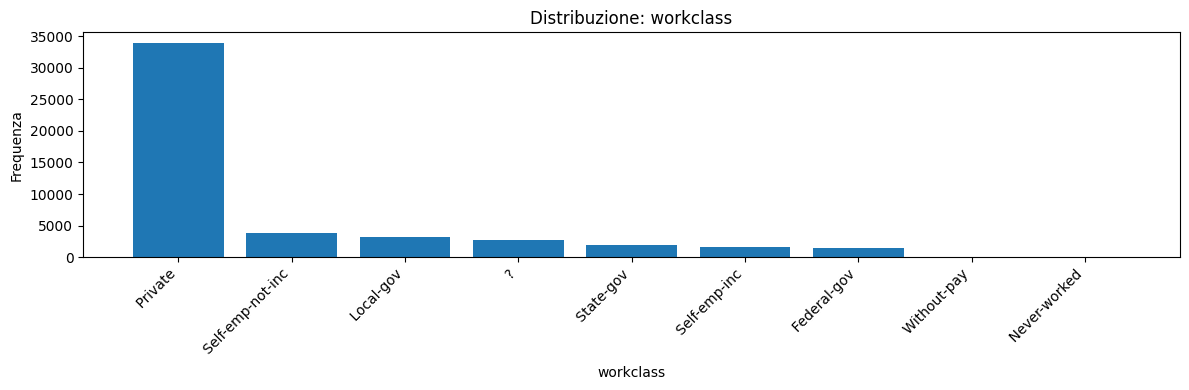

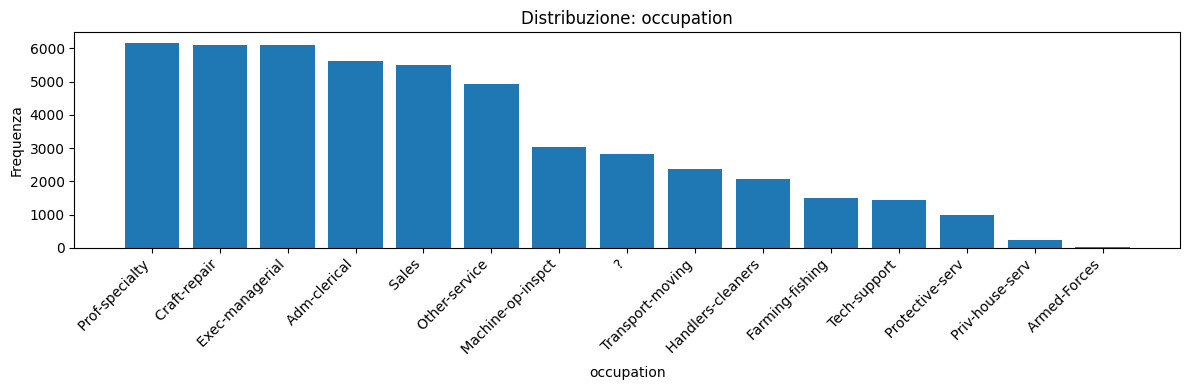

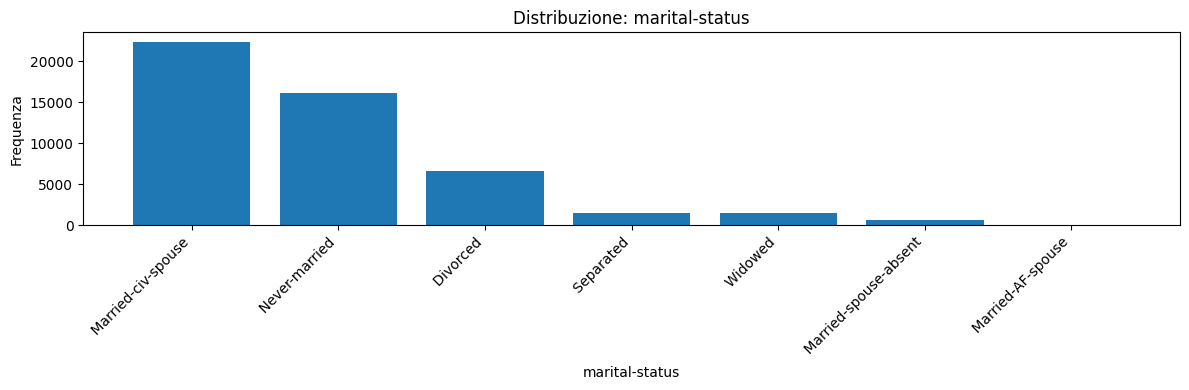

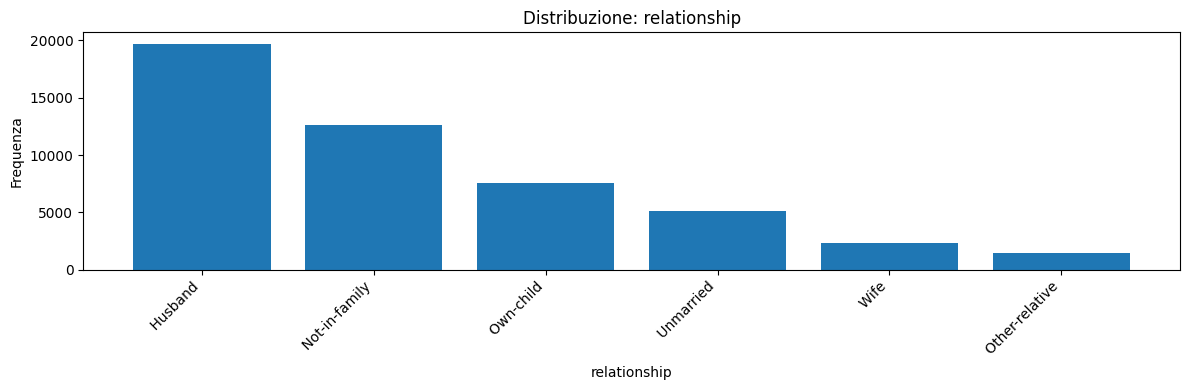

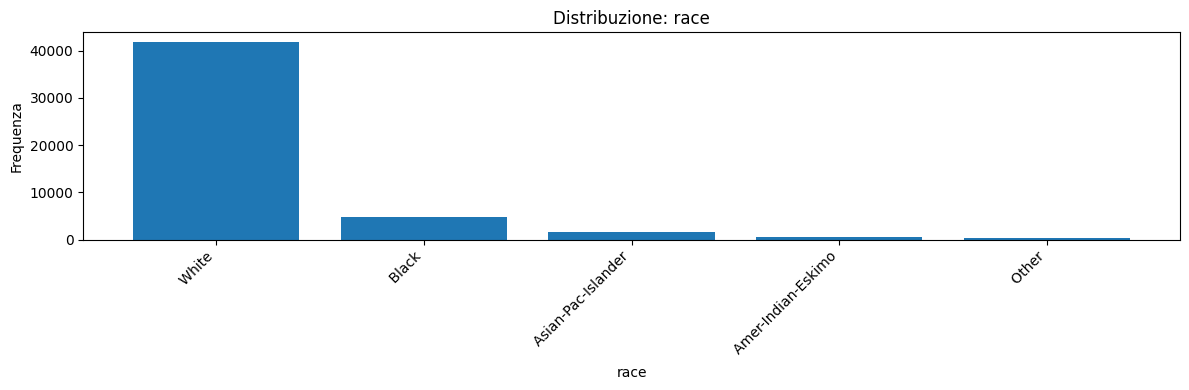

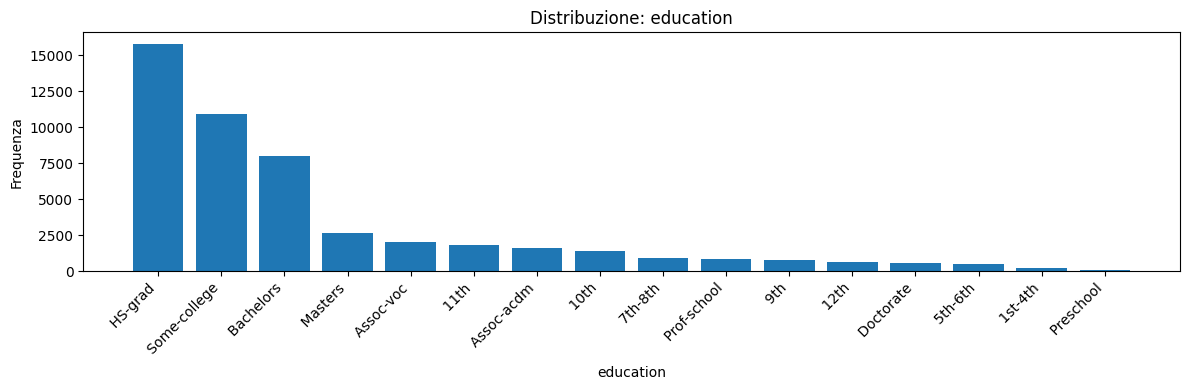

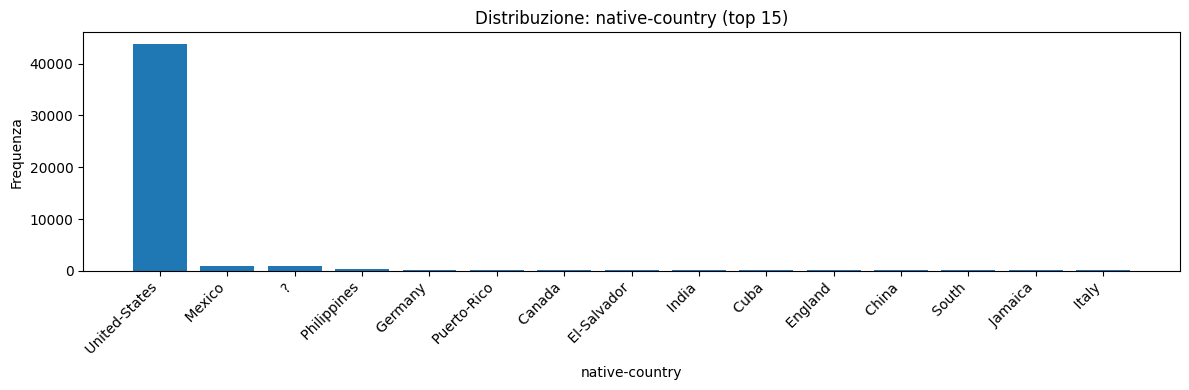

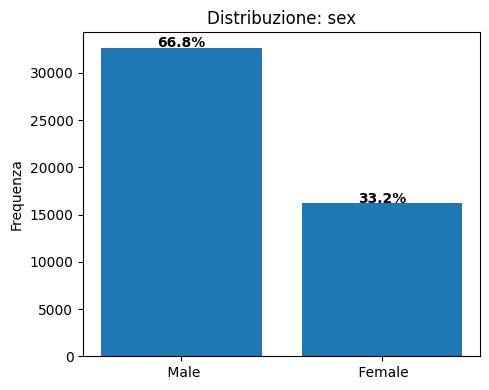

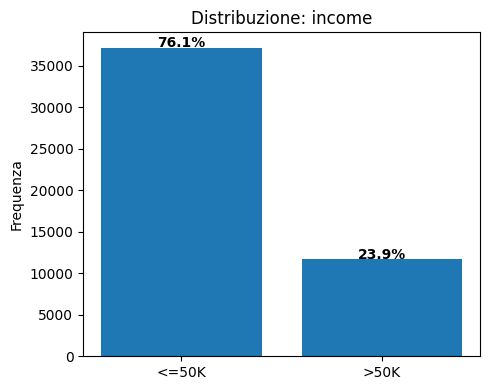

In [14]:


# Categoriche con molte categorie: bar chart frequenze
for col in ['workclass', 'occupation', 'marital-status', 
            'relationship', 'race', 'education']:
    counts = df[col].value_counts().reset_index()
    counts.columns = [col, 'count']
    
    plt.figure(figsize=(12, 4))
    plt.bar(counts[col], counts['count'])
    plt.title(f"Distribuzione: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequenza")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Native-country: troppe categorie, mostro solo top 15
counts_nc = df['native-country'].value_counts().reset_index().head(15)
counts_nc.columns = ['native-country', 'count']

plt.figure(figsize=(12, 4))
plt.bar(counts_nc['native-country'], counts_nc['count'])
plt.title("Distribuzione: native-country (top 15)")
plt.xlabel("native-country")
plt.ylabel("Frequenza")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Sex e income: solo 2 categorie, aggiungiamo anche le percentuali
for col in ['sex', 'income']:
    counts = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(1)
    
    plt.figure(figsize=(5, 4))
    plt.bar(counts.index, counts.values)
    plt.title(f"Distribuzione: {col}")
    plt.ylabel("Frequenza")
    for i, (val, p) in enumerate(zip(counts.values, pct.values)):
        plt.text(i, val + 50, f"{p}%", ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

I plot delle frequenze degli attributi nominali rispecchiano la popolazione americana media, più precisamente i dati riguardano principalmente i maschi bianchi americani sposati con income inferiori a 50k principalmente lavoranti nel settore privato con Hs-grad o college education.

Inoltre dall'ultimo grafico è possibile vedere che l'attributo binario target è **sbilanciato**, questo porta classificatori a privilegiare la classe meglio rappresentata, in seguito proveremo a mitigare questo problema.

Analizziamo ora le variabili numeriche in relazione alla variabile target

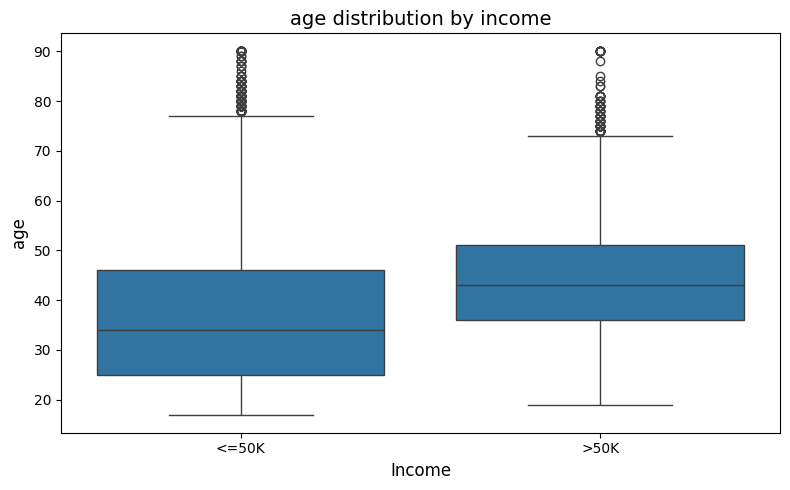

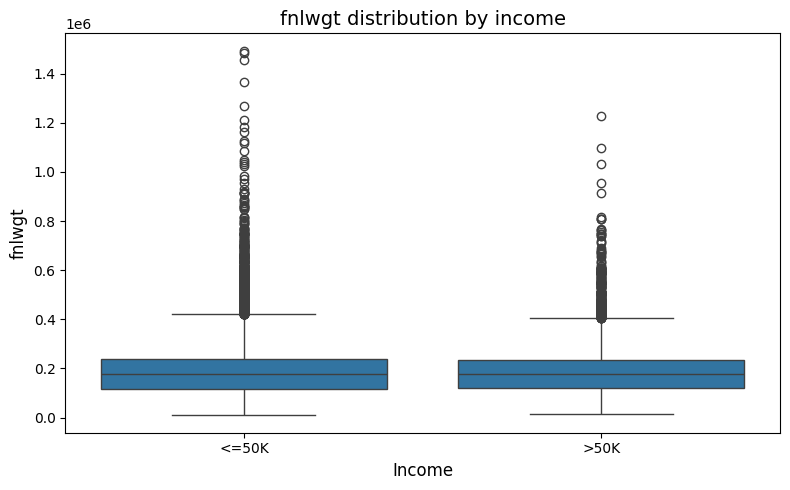

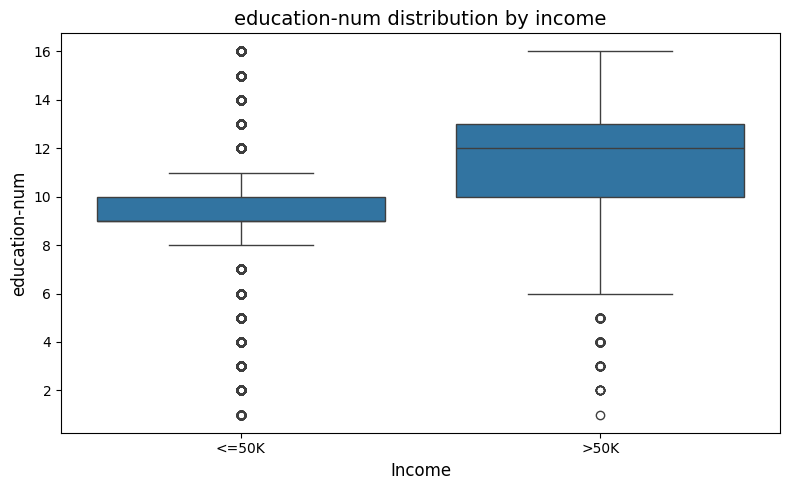

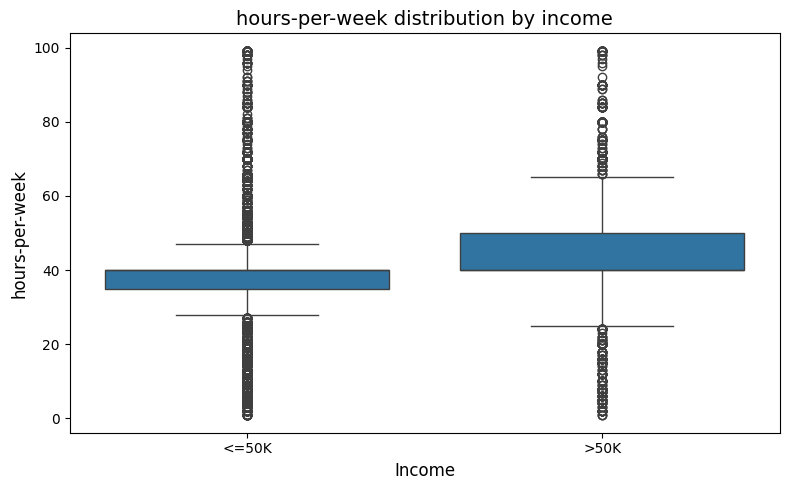

In [15]:
for col in ['age', 'fnlwgt', 'education-num', 'hours-per-week']:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='income', y=col, data=df)
    plt.title(f'{col} distribution by income', fontsize=14)
    plt.xlabel('Income', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.tight_layout()
    plt.show()

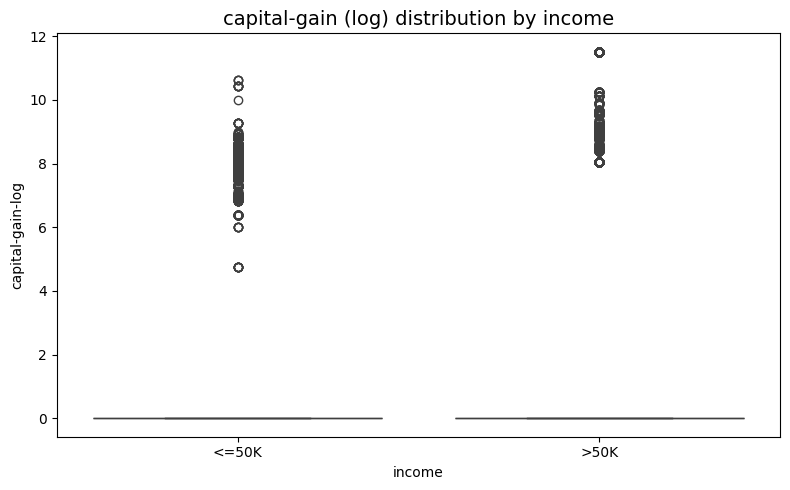

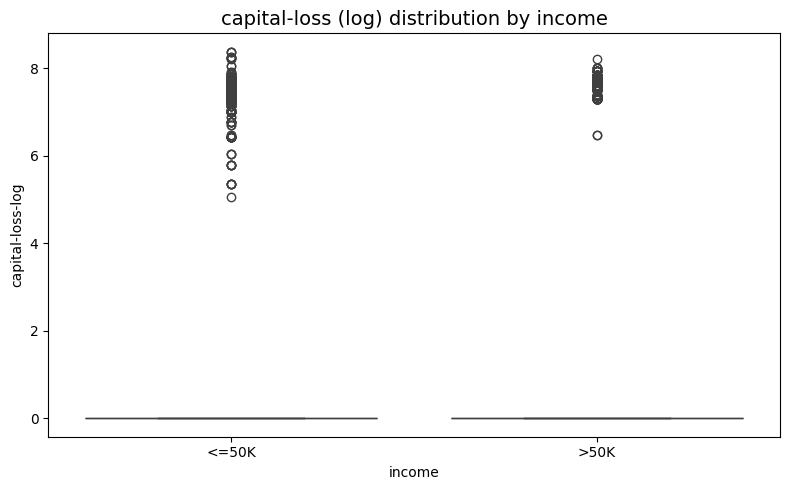

In [16]:

for col in ['capital-gain', 'capital-loss']:
    df[f'{col}-log'] = np.log1p(df[col])  
    
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='income', y=f'{col}-log', data=df)
    plt.title(f'{col} (log) distribution by income', fontsize=14)
    plt.tight_layout()
    plt.show()

Al grafico della capital-loss/gain è stata applicata una trasformazione logaritmica allo scopo di poter rendere più leggibile il grafico diminuendo la coda, ma rimane giustamente schiacciata verso 0 e poco informativa.

Cosa si intuisce dai grafici?
- Eta: tendenzialmente i soggetti con income >50k hanno una età media più alta rispetto a chi ha income minore.
- Fnlwgt: Sembra non mostrare differenze tra le due classi ==> questo vuol dire che per il modello predittivo è una informazione probabilmente **inutile**
- education-num: E' un numero proporzionale all'istruzione del soggetto e mostra una chiara correlazione positiva con la classe income >50k.
- Hour/wekk:Anche se la distribuzione è molto dispersa, tendenzialmente chi hai income >50k lavora di più.

In definita questi plot mostrano dei  pattern di correlazione tra età, education-num , ore di lavoro con il target tuttavia sembrano non essere troppo marcati ma semplicemente una tendenza. (questo sarà provato nell'analisi successiva delle correlazioni)

## 6. Studio delle correlazioni



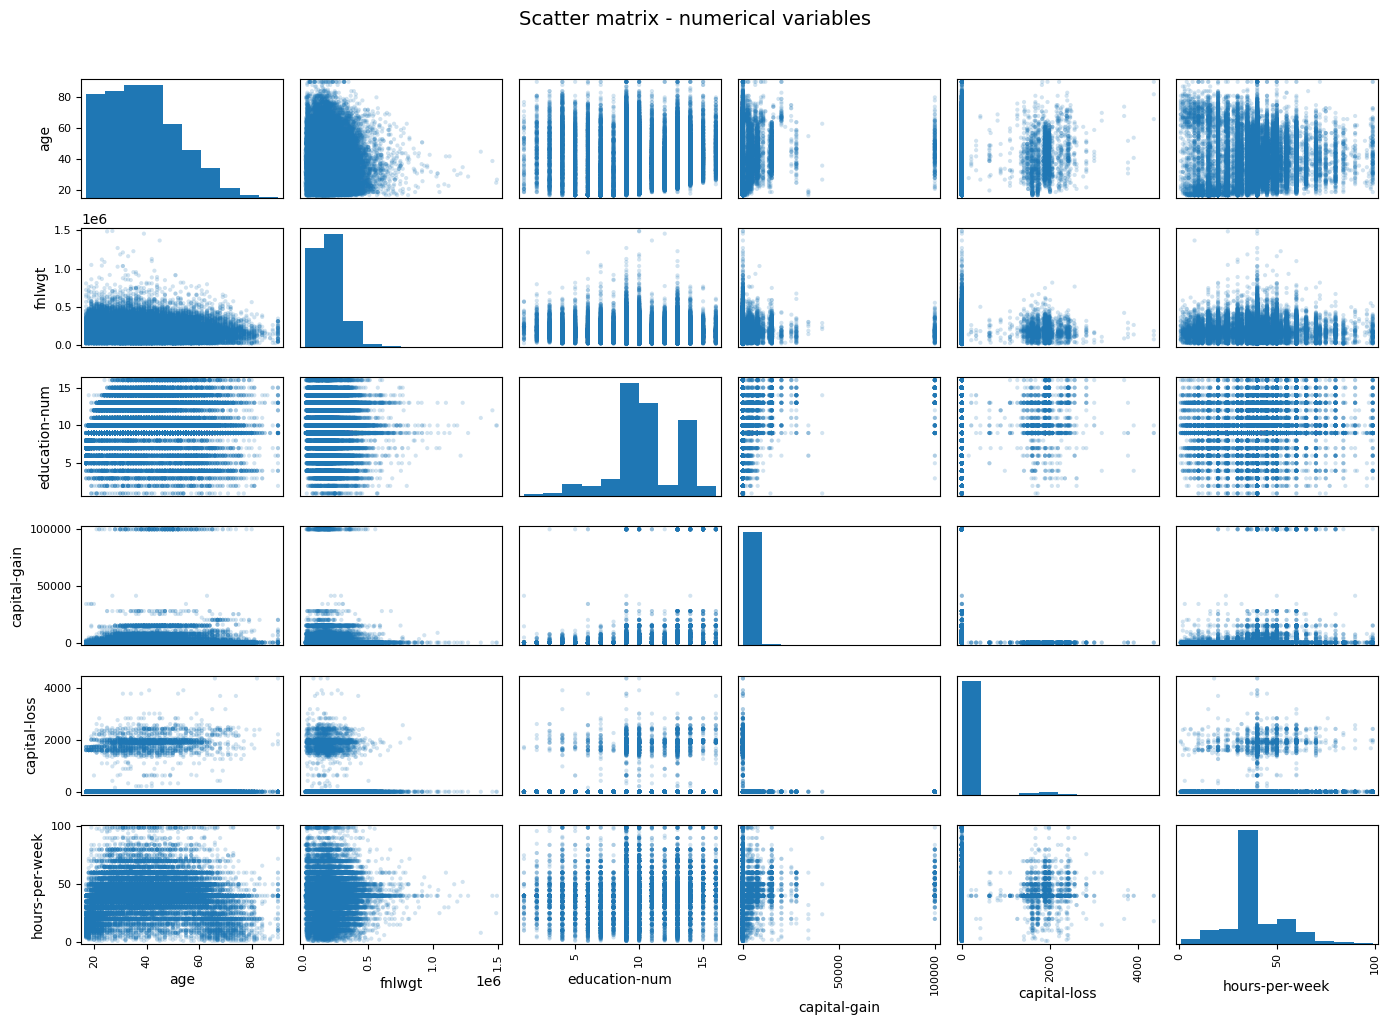

In [17]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 
                'capital-gain', 'capital-loss', 'hours-per-week']

# Scatter matrix
pd.plotting.scatter_matrix(df[numeric_cols], figsize=(14, 10), alpha=0.2, diagonal='hist')
plt.suptitle("Scatter matrix - numerical variables", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Dai grafici non sono preseti chiari pattern di correlazione lineare tra le varie feature del dataset, sicuramente si è lontani da pattern visti a lezione in particolare quelli lineari per cui si evita di usare Perason's privilengiando la correlazione di Spearman che sfrutta i Rank.

Calcolo quindi la Spearman matrix includendo la variabile target encodata come feature binaria.  (implementando quindi di fatto una point-biserial)

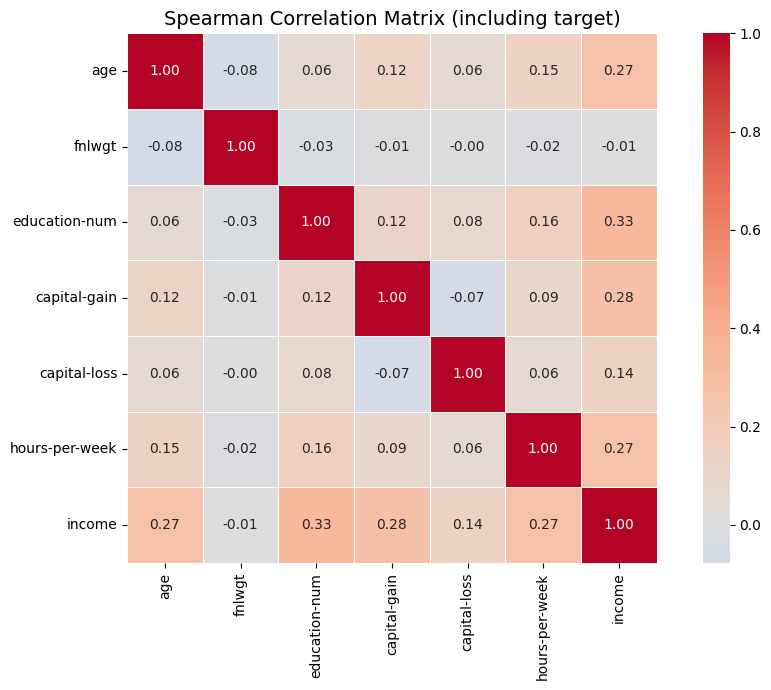

In [18]:
# Encoding temporaneo del target per il calcolo della correlazione (viene convertito in 0/1 e quindi di fatto viene calcolat la point-biserial correlation, che è un caso particolare di Spearman)
df_corr = df[numeric_cols].copy()
df_corr['income'] = (df['income'] == '>50K').astype(int)

# Spearman correlation includendo il target
spearman_corr = df_corr.corr(method='spearman')

plt.figure(figsize=(10, 7))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Spearman Correlation Matrix (including target)", fontsize=14)
plt.tight_layout()
plt.show()

I risultati mostrano quello intuito dai grafici sopra, fnlwgt ha una correlazione praticamente nulla, motivo per cui può anche essere scartata per i fini predittivi del modello.
Le altre variabili numeriche (oltre al capital loss) risultano invece mediamente correlate al target, informazioni che possono essere sfruttate dal predittore. 

Correlazione tra le variabili nominali, uso la Perason X^2 

In [19]:
from scipy.stats import chi2_contingency

categorical_cols = ['workclass', 'education', 'marital-status', 
                    'occupation', 'relationship', 'race', 'sex']

for col in categorical_cols:
    observed = pd.crosstab(index=df[col], columns=df['income'])
    statistic, p_value, dof, expected_freq = chi2_contingency(observed)
    
    print(f"{col} vs income:")
    print(f"  chi_2 statistic: {statistic:.2f}, p-value: {p_value:.4f}, dof: {dof}")
    
    if p_value < 0.05:
        print(f"  Associazione statisticamente significativa")
    else:
        print(f"  Nessuna associazione significativa")
    print()

workclass vs income:
  chi_2 statistic: 1610.61, p-value: 0.0000, dof: 8
  Associazione statisticamente significativa

education vs income:
  chi_2 statistic: 6536.91, p-value: 0.0000, dof: 15
  Associazione statisticamente significativa

marital-status vs income:
  chi_2 statistic: 9815.81, p-value: 0.0000, dof: 6
  Associazione statisticamente significativa

occupation vs income:
  chi_2 statistic: 5982.60, p-value: 0.0000, dof: 14
  Associazione statisticamente significativa

relationship vs income:
  chi_2 statistic: 10088.47, p-value: 0.0000, dof: 5
  Associazione statisticamente significativa

race vs income:
  chi_2 statistic: 486.96, p-value: 0.0000, dof: 4
  Associazione statisticamente significativa

sex vs income:
  chi_2 statistic: 2248.53, p-value: 0.0000, dof: 1
  Associazione statisticamente significativa



Lo studio della chi quadro tramite ipotesi H0 mostra p-value molto bassi (nulli) porta a rigettare l'ipotesi di non correlazione di ogni attributo con il target, questa è una buona notizia perchè vuol dire che ognuna di queste feature è informativa ai fini della predizione.

# Missing data


Nonostante il dataset presenta dei missing values in realtà esiste una sola riga con dei NaN, in particolare con tutti NaN, motivo per cui la cosa più sensata è semplicemente eliminarla.

In [20]:
# Righe con almeno un NaN
rows_with_nan = df[df.isna().any(axis=1)]
print(f"Righe con almeno un NaN: {len(rows_with_nan)}")
rows_with_nan

Righe con almeno un NaN: 1


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,capital-gain-log,capital-loss-log
2,38,Private,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df = df.dropna()

Tuttavia in realtà i dati NaN sono presenti ma encodati come "?" nel formatu standard UCI.

In [22]:
# Cerca valori '?' in tutte le colonne  
for col in df.columns:
    count = (df[col] == ' ?').sum()
    if count > 0:
        print(f"{col}: {count} / {len(df)} valori '?' ({count/len(df)*100:.2f}%)")

# Sostituisco i "?" con NaN in tutto il dataframe
df.replace(' ?', np.nan, inplace=True)

# Verifica che la situazione sia rimasta ovviamente uguale
missing = df.isna().sum()
for col in missing[missing > 0].index:
    n = missing[col]
    print(f"{col}: {n} / {len(df)} NaN ({n/len(df)*100:.2f}%)")

workclass: 2799 / 48844 valori '?' (5.73%)
occupation: 2809 / 48844 valori '?' (5.75%)
native-country: 857 / 48844 valori '?' (1.75%)
workclass: 2799 / 48844 NaN (5.73%)
occupation: 2809 / 48844 NaN (5.75%)
native-country: 857 / 48844 NaN (1.75%)


# MCAR ? 

Test di ipotesi


Colonne con missing: ['workclass', 'occupation', 'native-country']

Analisi missing per: workclass
Missing rows: 2799
Non-missing rows: 46045

Distribuzione income (missing):
income
<=50K    0.905323
>50K     0.094677
Name: proportion, dtype: float64

Distribuzione income (non missing):
income
<=50K    0.751938
>50K     0.248062
Name: proportion, dtype: float64


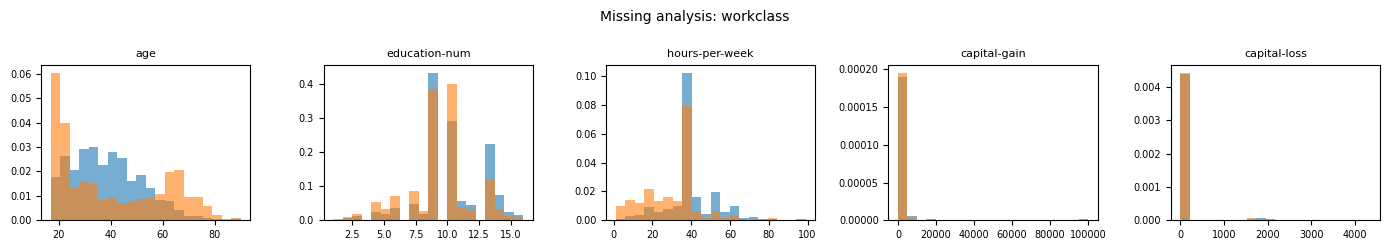


Analisi missing per: occupation
Missing rows: 2809
Non-missing rows: 46035

Distribuzione income (missing):
income
<=50K    0.90566
>50K     0.09434
Name: proportion, dtype: float64

Distribuzione income (non missing):
income
<=50K    0.751884
>50K     0.248116
Name: proportion, dtype: float64


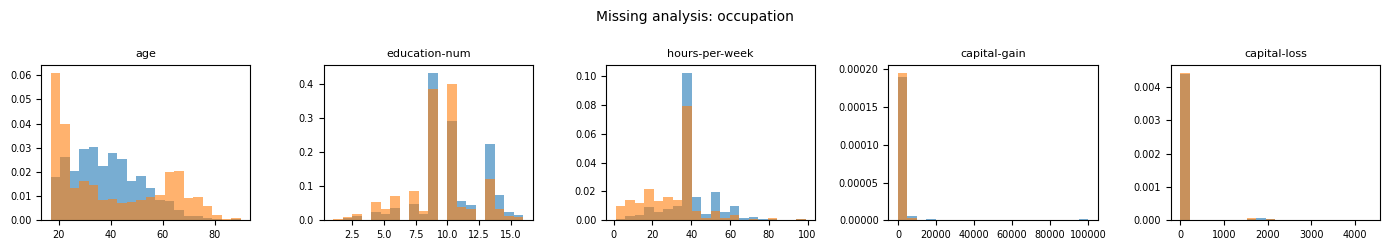


Analisi missing per: native-country
Missing rows: 857
Non-missing rows: 47987

Distribuzione income (missing):
income
<=50K    0.743291
>50K     0.256709
Name: proportion, dtype: float64

Distribuzione income (non missing):
income
<=50K    0.761039
>50K     0.238961
Name: proportion, dtype: float64


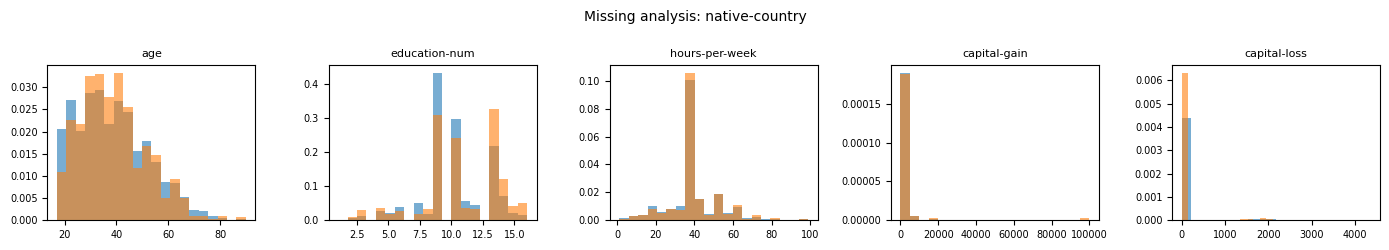

In [24]:


# feature numeriche da confrontare
numeric_features = ['age', 'education-num', 'hours-per-week', 
                    'capital-gain', 'capital-loss']

# colonne che contengono missing
missing_cols = df.columns[df.isna().any()].tolist()

print("Colonne con missing:", missing_cols)

for missing_col in missing_cols:
    print(f"\n{'='*60}")
    print(f"Analisi missing per: {missing_col}")
    print(f"{'='*60}")

    # dataframe separati
    df_missing = df[df[missing_col].isna()]
    df_not_missing = df[df[missing_col].notna()]

    print(f"Missing rows: {len(df_missing)}")
    print(f"Non-missing rows: {len(df_not_missing)}")

    # confronto distribuzione target
    print("\nDistribuzione income (missing):")
    print(df_missing['income'].value_counts(normalize=True))

    print("\nDistribuzione income (non missing):")
    print(df_not_missing['income'].value_counts(normalize=True))

    # grafici piccoli
    fig, axes = plt.subplots(1, len(numeric_features), figsize=(14, 2.5))

    for i, feature in enumerate(numeric_features):
        axes[i].hist(
            df_not_missing[feature],
            bins=20,
            alpha=0.6,
            density=True,
            label='not missing'
        )
        axes[i].hist(
            df_missing[feature],
            bins=20,
            alpha=0.6,
            density=True,
            label='missing'
        )

        axes[i].set_title(feature, fontsize=8)
        axes[i].tick_params(axis='both', labelsize=7)

    plt.suptitle(f"Missing analysis: {missing_col}", fontsize=10)
    plt.tight_layout()
    plt.show()

# Metodo di imputazione


Visto che tutte le variabili che presentano missing data sono categoriche uso come metodo di imputazione la MODA.

Tuttavia è evidente dal test di ipotesi che:
- workclass
- occupation

Siano due categorie di missing values non MCAR, infatti si può notare la differenza di distribuzioni dell'età ma ancora più rilevante avere una forte differenze sul TARGET, questo mostra che il missing values è esso stesso una feature informativa, motivo per cui questi due attributi li lascio come categoria "Unknown".
(scelta motivata anche dalla letteratura già presente)

Native-country sembra invece ragionevolmente MCAR motivo per cui uso la moda e controllo di non alterare la distribuzione altrimenti ne cambio il contenuto informativo all'interno del dataset. 

In [28]:
# Salva le distribuzioni PRIMA dell'imputazione
df_before = df.copy()


cols_with_missing = ['workclass', 'occupation']
for col in cols_with_missing:
    df[col] = df[col].fillna('Unknown')
    print(f"{col}: NaN  modellati come feature Unknown")

# Imputazione con la moda
cols_with_nan = ['native-country']
for col in cols_with_nan:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)  # fix: assegnazione diretta invece di inplace=True
    print(f"{col}: NaN imputati con moda '{moda}'")

workclass: NaN  modellati come feature Unknown
occupation: NaN  modellati come feature Unknown
native-country: NaN imputati con moda ' United-States'


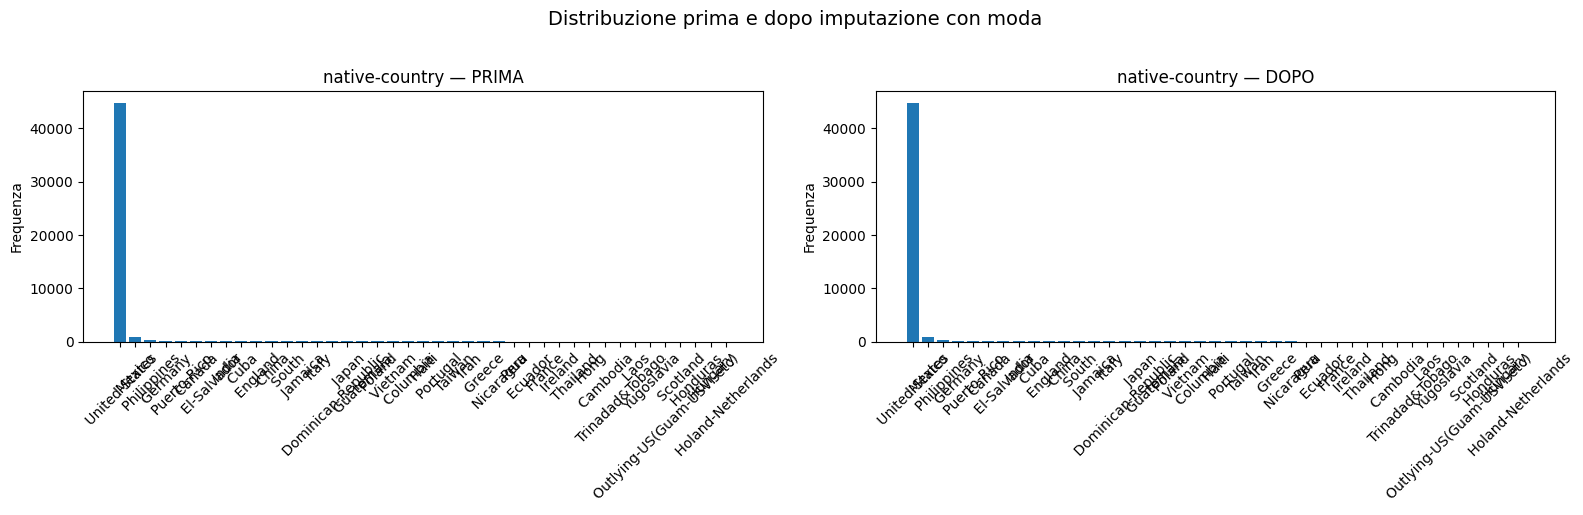

In [ ]:
fig, axes = plt.subplots(nrows=len(cols_with_nan),ncols=2,figsize=(16, 5 * len(cols_with_nan)))

if len(cols_with_nan) == 1:
    axes = np.array([axes])

for i, col in enumerate(cols_with_nan):

    # PRIMA imputazione
    before_counts = df_before[col].value_counts(dropna=False)
    axes[i, 0].bar(before_counts.index.astype(str),
                   before_counts.values)
    axes[i, 0].set_title(f"{col} — PRIMA", fontsize=12)
    axes[i, 0].set_ylabel("Frequenza")
    axes[i, 0].tick_params(axis='x', rotation=45)

    # DOPO imputazione
    after_counts = df[col].value_counts(dropna=False)
    axes[i, 1].bar(after_counts.index.astype(str),
                   after_counts.values)
    axes[i, 1].set_title(f"{col} — DOPO", fontsize=12)
    axes[i, 1].set_ylabel("Frequenza")
    axes[i, 1].tick_params(axis='x', rotation=45)

plt.suptitle("Distribuzione prima e dopo imputazione con moda",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Le distribuzioni  essenzialmente non sono state alterate, grazie anche al fatto che i dati da imputare erano solo il 2%, motivo per cui decido di mantenere l'imputazione fatta.

# Preparazione dei dati per un task di classificazione

L'obiettivo è quello di preparare i dati per la classificazione binaria sul target *income* motivo per cui splittiamo il dataset in train e test, procedendo con una visualizzazione grafica dello spazio delle feature, outlier detection ed eventuale feature engineeniring per aiutare i classificatori.

Prima di tutto è necessario trasformare le variabili categoriche in numeriche tramite dummyfication ed eliminare una categoria per ridondanza. (ad esempio per sex teniamo solo male {0/1}).

Tuttavia una diretta dummificazione di tutte le variabili categoriche potrebbe portare ad un numero esponenziale di feature rendendone lo spazio delle feature inutilmente grande e complesso.

Per questo motivo controllo i valori unici assunti dalle varie variabili e possibili trasformazioni sensate da usare.


In [31]:
# Numero di valori unici per ogni variabile categorica
categorical_cols = ['workclass', 'education', 'marital-status', 
                    'occupation', 'relationship', 'race', 'sex', 'native-country']

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} valori unici → {df[col].nunique()-1} dummy")
    print(f"  {df[col].unique().tolist()}\n") 

workclass: 9 valori unici → 8 dummy
  [' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov', ' Local-gov', 'Unknown', ' Self-emp-inc', ' Without-pay', ' Never-worked']

education: 16 valori unici → 15 dummy
  [' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th', ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th', ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th', ' Preschool', ' 12th']

marital-status: 7 valori unici → 6 dummy
  [' Never-married', ' Married-civ-spouse', ' Divorced', ' Married-spouse-absent', ' Separated', ' Married-AF-spouse', ' Widowed']

occupation: 15 valori unici → 14 dummy
  [' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners', ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair', ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct', ' Tech-support', 'Unknown', ' Protective-serv', ' Armed-Forces', ' Priv-house-serv']

relationship: 6 valori unici → 5 dummy
  [' Not-in-family', ' Husband', ' Wife', ' Own-child',

In [32]:
total_dummies = sum(df[col].nunique()-1 for col in categorical_cols)
print(f"Totale colonne dummy che verrebbero create: {total_dummies}")

Totale colonne dummy che verrebbero create: 93


93 dummy columns sono decisamente troppe, renderebbero solo più complesso per il predittore uno spazio delle feature così grande.

Trasformazioni per agevolare una dummyfication con meno colonne:
- education ==> viene rimossa visto che nel dataset è già presente l'attributo numerico che lo rappresenta
- race / native-country ==> visto la loro distribuzioni le trasformo in ["white","other"] e ["United-States","other"] andando a evitare molte colonne che sarebbero molto poco rappresentate
- workclass ==> sembra sensato raggrupparle in questo modo:
1) Private                          → Private
2) Self-emp-not-inc, Self-emp-inc   → Self-employed
3) Federal-gov, Local-gov, State-gov → Government
4) Unknown
Without-pay, Never-worked        → Other
- marital status ==> per semplicità si può binarizzare in :
1) Married-civ-spouse, Married-AF-spouse → Married
2) tutto il resto                         → Not-married
- relationship ==> sembra ridondante con l'informazione di "marital-status" sopratutto ai fini del target per cui la elimino
- occupation ==> non effettuo trasformazioni quindi dummyficandola completamente altrimenti in questo caso ritengo che porterebbe perdita di informazione rilevante   (il lavoro penso sia una delle feature più importanti)

In [33]:
# 1. Elimina education (già rappresentata da education-num) e relationship (ridondante)
df = df.drop(columns=['education', 'relationship'])

# 2. Binarizza race → White / Other
df['race'] = df['race'].apply(lambda x: 'White' if x == ' White' else 'Other')

# 3. Binarizza native-country → United-States / Other
df['native-country'] = df['native-country'].apply(lambda x: 'United-States' if x == ' United-States' else 'Other')

# 4. Raggruppa workclass
workclass_map = {
    ' Private'         : 'Private',
    ' Self-emp-not-inc': 'Self-employed',
    ' Self-emp-inc'    : 'Self-employed',
    ' Federal-gov'     : 'Government',
    ' Local-gov'       : 'Government',
    ' State-gov'       : 'Government',
    ' Without-pay'     : 'Other',
    ' Never-worked'    : 'Other',
    'Unknown'          : 'Unknown'
}
df['workclass'] = df['workclass'].map(workclass_map)

# 5. Binarizza marital-status → Married / Not-married
df['marital-status'] = df['marital-status'].apply(
    lambda x: 'Married' if x in [' Married-civ-spouse', ' Married-AF-spouse'] else 'Not-married'
)

# 6. Dummification con drop_first=True  (elimina una categoria per evitare )   
df = pd.get_dummies(df, columns=['workclass', 'marital-status', 'occupation', 
                                  'race', 'sex', 'native-country'],
                    drop_first=True, dtype='i')

print(f"Shape finale: {df.shape}")
print(f"\nColonne dopo dummification:")
print(df.columns.tolist())

Shape finale: (48844, 31)

Colonne dopo dummification:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income', 'capital-gain-log', 'capital-loss-log', 'workclass_Other', 'workclass_Private', 'workclass_Self-employed', 'workclass_Unknown', 'marital-status_Not-married', 'occupation_ Armed-Forces', 'occupation_ Craft-repair', 'occupation_ Exec-managerial', 'occupation_ Farming-fishing', 'occupation_ Handlers-cleaners', 'occupation_ Machine-op-inspct', 'occupation_ Other-service', 'occupation_ Priv-house-serv', 'occupation_ Prof-specialty', 'occupation_ Protective-serv', 'occupation_ Sales', 'occupation_ Tech-support', 'occupation_ Transport-moving', 'occupation_Unknown', 'race_White', 'sex_ Male', 'native-country_United-States']


Le colonne risultanti sono 31, circa 20 dummy invece delle 94 che si sarebbero create altrimenti.

In [34]:
#Binarizzo il target: '>50K' → 1, '<=50K' → 0 per le analisi successive  
df['income'] = (df['income'] == '>50K').astype(int)

# Verifica
print(df['income'].value_counts())

income
0    37157
1    11687
Name: count, dtype: int64


Split del test & train dataset

Stratify permette di mantenere la distribuzione di income sia nel test che nel train, splitto in questo momento così che le future trasformazioni riguardino solo il train set.


In [35]:
from sklearn.model_selection import train_test_split

data_train, data_test = train_test_split(df, test_size=0.3, random_state=0, stratify=df['income'])

# PCA

Lo scopo è per la visualizzazione delle due classi, ci permette di capire quanto sono separate e quindi cosa aspettarci dal classificatore lineare.  

La funzione è semplicemente una variante di quella presentata nel notebook.

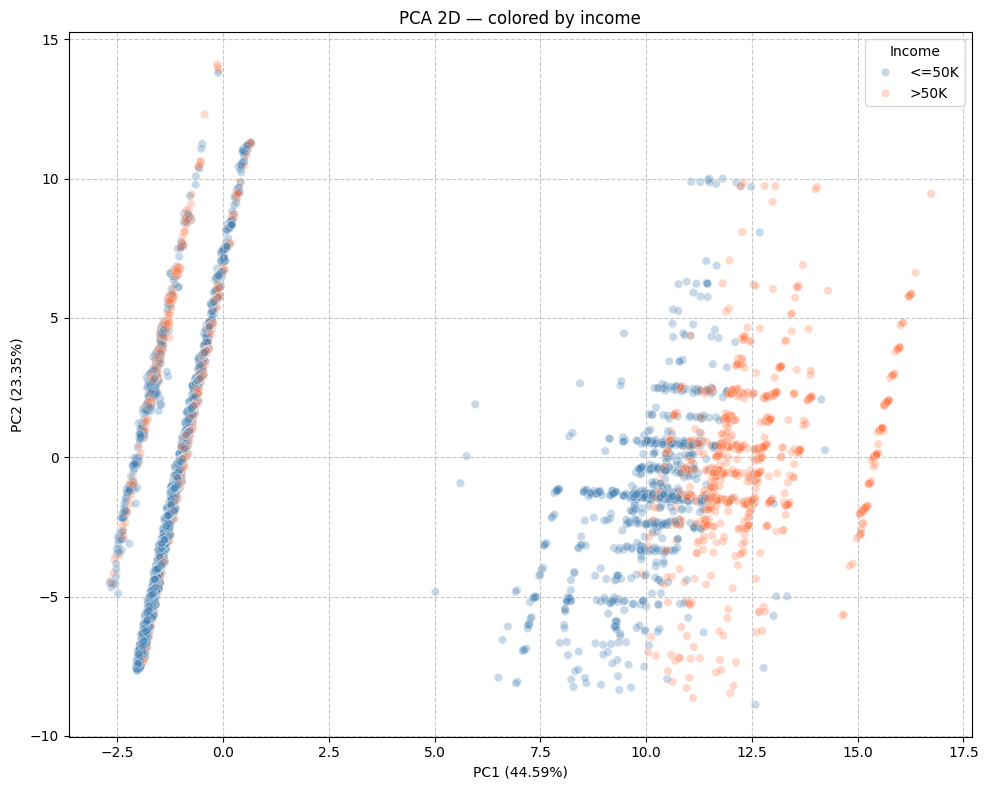

Total explained variance (PC1+PC2): 67.94%
PC1: 44.59%
PC2: 23.35%


In [36]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.decomposition import PCA

def plot_pca(df, target_col='income', n_components=2, figsize=(10, 8), random_state=42):
    """
    Perform PCA on a pandas DataFrame and plot the results colored by target variable.
    
    Parameters:
    -----------
    df           : pandas DataFrame dopo dummification e scaling
    target_col   : colonna target da usare per il colore
    n_components : numero di componenti principali (default: 2)
    figsize      : dimensione figura (default: (10, 8))
    random_state : riproducibilità (default: 42)
    """
    # Separa feature e target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Perform PCA
    pca = PCA(n_components=n_components, random_state=random_state)
    principal_components = pca.fit_transform(X)

    # Create a DataFrame with the principal components
    pc_df = pd.DataFrame(
        data=principal_components,
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    pc_df['income'] = y.values

    # Calculate explained variance
    explained_variance = pca.explained_variance_ratio_ * 100

    # Plot
    plt.figure(figsize=figsize)
    ax = sns.scatterplot(
        x='PC1', y='PC2',
        hue='income',
        data=pc_df,
        alpha=0.3,
        palette={0: 'steelblue', 1: 'coral'}
    )
    plt.xlabel(f'PC1 ({explained_variance[0]:.2f}%)')
    plt.ylabel(f'PC2 ({explained_variance[1]:.2f}%)')
    plt.title('PCA 2D — colored by income')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Fix legenda mantenendo i colori corretti
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=['<=50K', '>50K'], title='Income')

    plt.tight_layout()
    plt.show()

    # Print explained variance
    print(f'Total explained variance (PC1+PC2): {sum(explained_variance):.2f}%')
    for i, variance in enumerate(explained_variance):
        print(f'PC{i+1}: {variance:.2f}%')

    return pca, pc_df


from sklearn.preprocessing import RobustScaler

# Log1p altrimenti domina la varianza   (Log trasformation) 
data_train['capital-gain'] = np.log1p(data_train['capital-gain'])
data_train['capital-loss'] = np.log1p(data_train['capital-loss'])
data_test['capital-gain'] = np.log1p(data_test['capital-gain'])  
data_test['capital-loss'] = np.log1p(data_test['capital-loss'])

numeric_cols_to_scale = ['age', 'fnlwgt', 'education-num', 
                          'capital-gain', 'capital-loss', 'hours-per-week']

#scaling temporaneo solo per la PCA
data_train_tmp = data_train.copy()
scaler_tmp = RobustScaler()
data_train_tmp[numeric_cols_to_scale] = scaler_tmp.fit_transform(data_train_tmp[numeric_cols_to_scale])

pca, pc_df = plot_pca(data_train_tmp, target_col='income')

del data_train_tmp, scaler_tmp

Il grafico mostra una discreta (non ottimale) separazione lineare delle classi, il che fa presagire che un modello lineare non è detto abbia ottime performane, ricordandosi sempre tuttavia di star facendo una valutazione nello spazio 2D e non quello di predizione del modello.

# Detection degli outlier

Partiamo prima trasformando le feature per essere adatte ad algoritmi che sfruttano distanze euclidee come DB-scan.

Una box-cox ha lo scopo di trasformare la distribuzione in simil gaussiana.

Robust scaler ha lo scopo di scalare in modo  robusto ovvero senza essere biased da valori "estremi" usando quindi mediana ed IQR.

NB: ho fittato lo scaler e lambda della box-cox (es i suoi valori di mediana ed IQR) solo sul train e poi applicata al test 

Lambda trovati da Box-Cox:
  age: λ = 0.1851, shift = 0.0000
  fnlwgt: λ = 0.4099, shift = 0.0000
  education-num: λ = 1.3061, shift = 0.0000
  hours-per-week: λ = 0.9853, shift = 0.0000


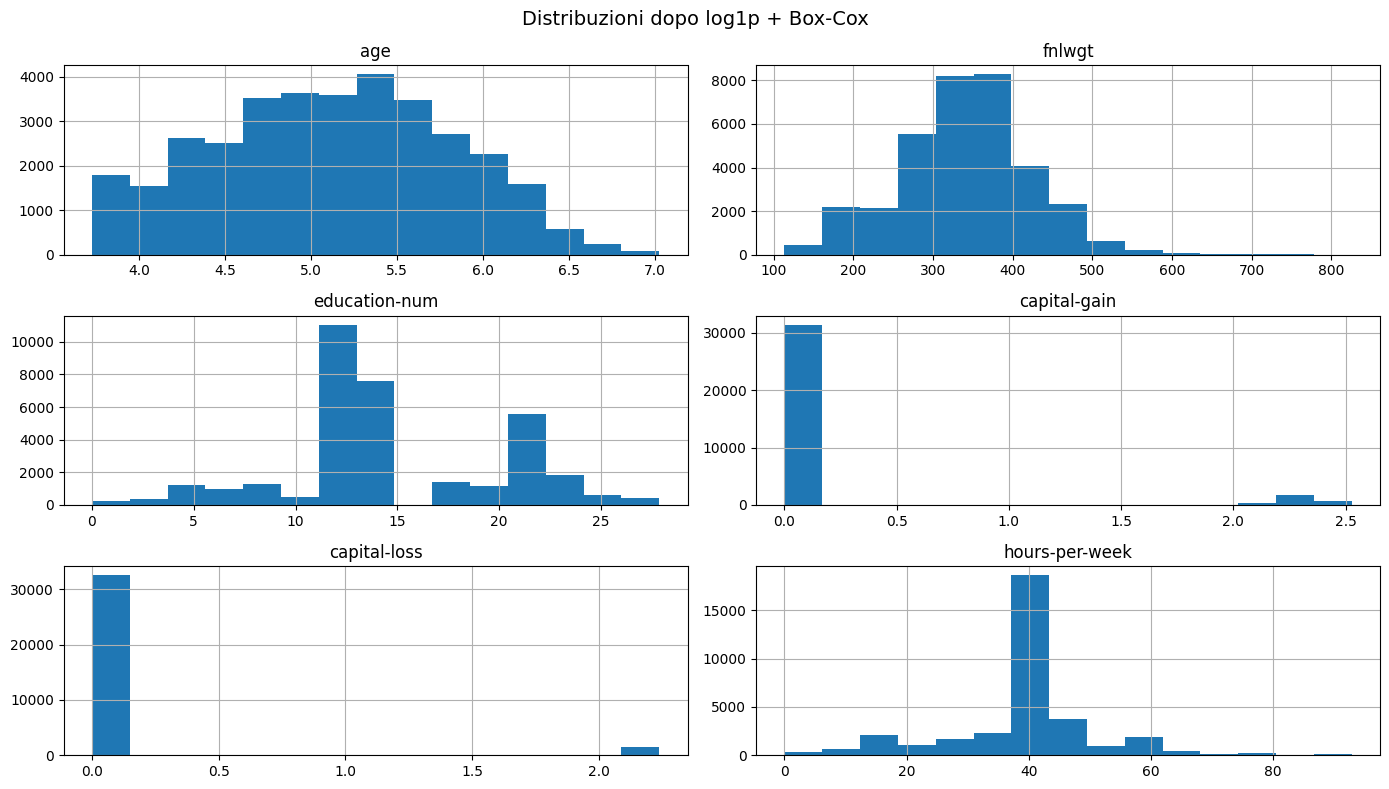

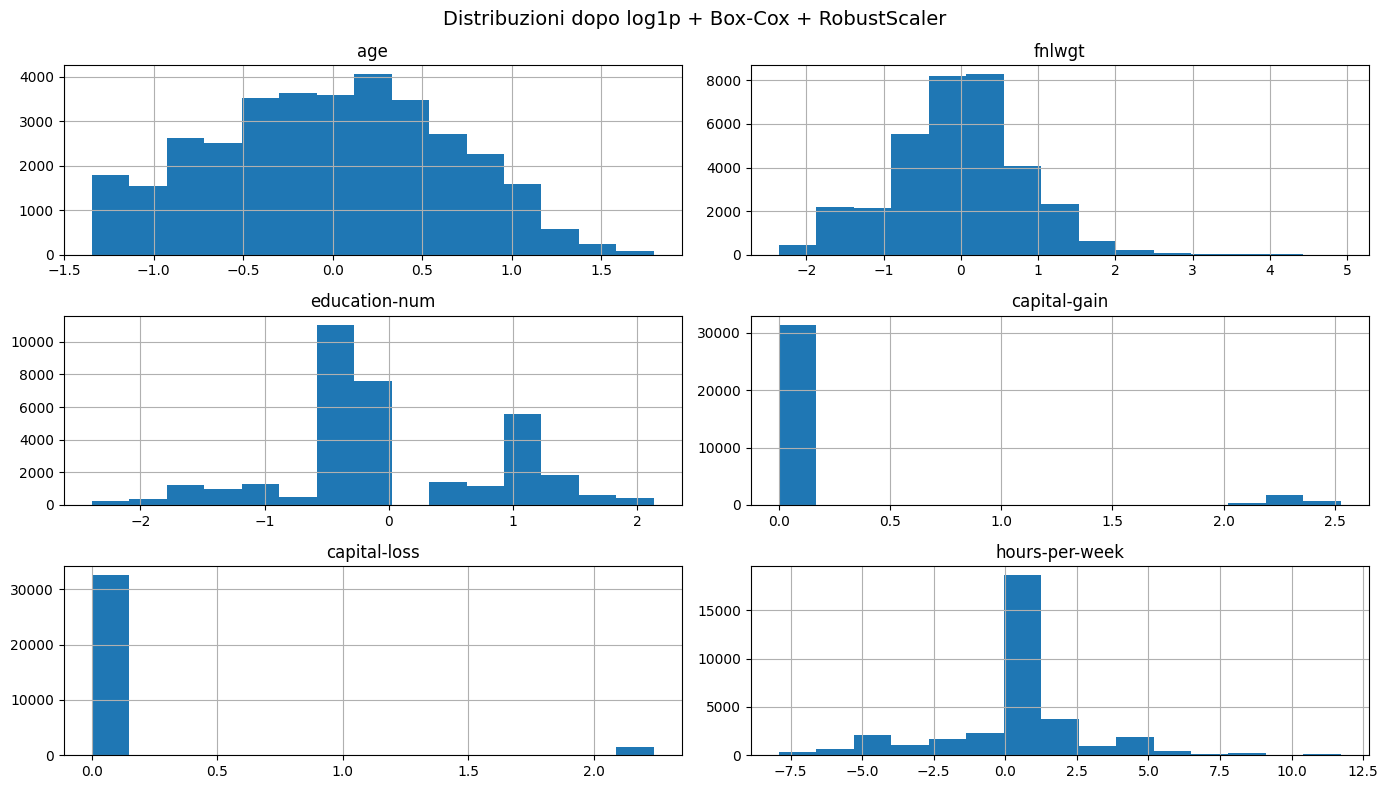


Statistiche finali train:
             age     fnlwgt  education-num  capital-gain  capital-loss  \
count  34190.000  34190.000      34190.000     34190.000     34190.000   
mean      -0.017     -0.046          0.060         0.186         0.099   
std        0.667      0.833          0.828         0.624         0.450   
min       -1.346     -2.358         -2.392         0.000         0.000   
25%       -0.505     -0.557         -0.323         0.000         0.000   
50%        0.000      0.000          0.000         0.000         0.000   
75%        0.495      0.443          0.677         0.000         0.000   
max        1.795      4.919          2.133         2.527         2.239   

       hours-per-week  
count       34190.000  
mean            0.086  
std             2.498  
min            -7.912  
25%             0.000  
50%             0.000  
75%             1.000  
max            11.721  


In [37]:
from scipy import stats
from sklearn.preprocessing import RobustScaler

numeric_vars = ['age', 'fnlwgt', 'education-num', 
                'capital-gain', 'capital-loss', 'hours-per-week']

# Colonne su cui applicare Box-Cox (escludi capital-gain e capital-loss)
boxcox_vars = ['age', 'fnlwgt', 'education-num', 'hours-per-week']
log1p_vars  = ['capital-gain', 'capital-loss']

transformed_train = data_train[numeric_vars].copy()
transformed_test  = data_test[numeric_vars].copy()

# ── Log1p su capital-gain e capital-loss ──────────────────────────────
transformed_train[log1p_vars] = np.log1p(transformed_train[log1p_vars])
transformed_test[log1p_vars]  = np.log1p(transformed_test[log1p_vars])

# ── Box-Cox solo sulle altre feature ──────────────────────────────────
lambda_dict = {}
for col in boxcox_vars:
    min_val = transformed_train[col].min()
    shift = -min_val + 1e-4 if min_val <= 0 else 0
    new_values, lambda_val = stats.boxcox(transformed_train[col] + shift)
    lambda_dict[col] = (lambda_val, shift)
    transformed_train[col] = new_values
    transformed_test[col]  = stats.boxcox(transformed_test[col] + shift, lmbda=lambda_val)

print("Lambda trovati da Box-Cox:")
for col, (lam, shift) in lambda_dict.items():
    print(f"  {col}: λ = {lam:.4f}, shift = {shift:.4f}")

transformed_train.hist(bins=15, figsize=(14, 8))
plt.suptitle("Distribuzioni dopo log1p + Box-Cox", fontsize=14)
plt.tight_layout()
plt.show()

# ── RobustScaler ───────────────────────────────────────────────────────
scaler = RobustScaler()
transformed_train_scaled = pd.DataFrame(
    scaler.fit_transform(transformed_train),
    columns=numeric_vars
)
transformed_test_scaled = pd.DataFrame(
    scaler.transform(transformed_test),
    columns=numeric_vars
)

transformed_train_scaled.hist(bins=15, figsize=(14, 8))
plt.suptitle("Distribuzioni dopo log1p + Box-Cox + RobustScaler", fontsize=14)
plt.tight_layout()
plt.show()

print("\nStatistiche finali train:")
print(transformed_train_scaled.describe().round(3))

Si può notare graficamente che le distribuzioni sono state per quanto possibili rese più simili ad una normale mentre la mediana adesso è effettivamente 0 grazie al robust scaler

Una prima metrica ingenua è la "Box-plot method", una metrica non parametrica che considera outlier come i punti fuori dal range  (Q1-1.5*IQR,  Q3+1.5*IQR)

In [38]:
# Outlier detection con metodo IQR su X_train (solo numeriche)
outlier_report = {}

for col in numeric_vars:
    Q1 = transformed_train_scaled[col].quantile(0.25)
    Q3 = transformed_train_scaled[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = transformed_train_scaled[(transformed_train_scaled[col] < lower) | (transformed_train_scaled[col] > upper)]
    outlier_report[col] = {
        'n_outliers': len(outliers),
        'pct': round(len(outliers) / len(transformed_train_scaled) * 100, 2),
        'lower_bound': round(lower, 3),
        'upper_bound': round(upper, 3)
    }
    
print("Outlier detection — metodo IQR:\n")
for col, info in outlier_report.items():
    print(f"{col}:")
    print(f"  range accettato: [{info['lower_bound']}, {info['upper_bound']}]")
    print(f"  outliers: {info['n_outliers']} / {len(transformed_train_scaled)} ({info['pct']}%)\n")


Outlier detection — metodo IQR:

age:
  range accettato: [-2.005, 1.995]
  outliers: 0 / 34190 (0.0%)

fnlwgt:
  range accettato: [-2.057, 1.943]
  outliers: 387 / 34190 (1.13%)

education-num:
  range accettato: [-1.823, 2.177]
  outliers: 564 / 34190 (1.65%)

capital-gain:
  range accettato: [0.0, 0.0]
  outliers: 2786 / 34190 (8.15%)

capital-loss:
  range accettato: [0.0, 0.0]
  outliers: 1581 / 34190 (4.62%)

hours-per-week:
  range accettato: [-1.5, 2.5]
  outliers: 9514 / 34190 (27.83%)



Questo risultato era già suggerito dai plot iniziali che mostrano distribuzioi asimmetriche e con valori "estremi" che però sembravano essere legittimi, motivo per cui ritengo necessario l'utilizzo di qualche metodo più sofisticato.

# Mahalanobis distance

In [39]:
from sklearn.covariance import MinCovDet
from scipy.stats import chi2

# Usa le numeriche scalate
cols = numeric_vars
X_mah = transformed_train_scaled[cols].values

# Fit MinCovDet solo su train
robust_cov = MinCovDet(random_state=0).fit(X_mah)

# Calcola distanza di Mahalanobis al quadrato
mahalanobis_squared = robust_cov.mahalanobis(X_mah)

# Soglia chi2 al 99° percentile
soglia = chi2.ppf(0.99, df=len(cols))
print(f"Soglia χ² (99 °, df={len(cols)}): {soglia:.3f}")

bool_outliers = mahalanobis_squared > soglia
print(f"Outlier rilevati: {bool_outliers.sum()} / {len(X_mah)} ({bool_outliers.sum()/len(X_mah)*100:.2f}%)")


Soglia χ² (99 °, df=6): 16.812
Outlier rilevati: 9648 / 34190 (28.22%)


La metrica, nonostante un valore alto dato al parametro della chi2, considera circa il 28% del dataset come outlier, il chè risulta un valore sicuramente anomalo.
Ritengo che il problema principale sia:
- è una metrica statistica come specificato nelle slide che assume la disposizioni NORMALE degli attributi, nonostante si è applicata la box-cox alcune distribuzioni risultano  lontane da una normale.
- inoltre la metrica si basa sul "fitting" di ellissoidi sui dati, ma il dataset è sbilanciato e se supponiamo che le due classi siano in parte clusterizzate in modo separato potrebbe considerare il cluster meno rappresentato (income >50k) come sostanzialmente outlier.

Controllo quindi questa ultima ipotesi:

In [40]:
total_income1 = data_train['income'].sum()  # totale persone con income=1

outliers_income1 = data_train[bool_outliers]['income'].sum()
inliers_income1  = data_train[~bool_outliers]['income'].sum()

print(f"Totale income >50K: {total_income1}")
print(f"  → classificati come outlier: {outliers_income1} ({outliers_income1/total_income1*100:.1f}%)")
print(f"  → classificati come inlier:  {inliers_income1} ({inliers_income1/total_income1*100:.1f}%)")

total_income0 = (data_train['income'] == 0).sum()  # totale persone con income=0

outliers_income0 = (data_train[bool_outliers]['income'] == 0).sum()
inliers_income0  = (data_train[~bool_outliers]['income'] == 0).sum()

print(f"Totale income <=50K: {total_income0}")
print(f"  → classificati come outlier: {outliers_income0} ({outliers_income0/total_income0*100:.1f}%)")
print(f"  → classificati come inlier:  {inliers_income0} ({inliers_income0/total_income0*100:.1f}%)")

Totale income >50K: 8181
  → classificati come outlier: 3338 (40.8%)
  → classificati come inlier:  4843 (59.2%)
Totale income <=50K: 26009
  → classificati come outlier: 6310 (24.3%)
  → classificati come inlier:  19699 (75.7%)


L'ipotesi sembra verificare che i soggetti con income >50k hanno più probabilità di essere outlier, motivo per cui scarto questa metrica di detection.

# Density Based distance  (DB-scan)

Uso quindi le feature numeriche con:
- numero sample per un cluster:  2*d   (come da slide)
- eps --> deciso tramite elbow method dal grafico dei kNN

min_samples: 12


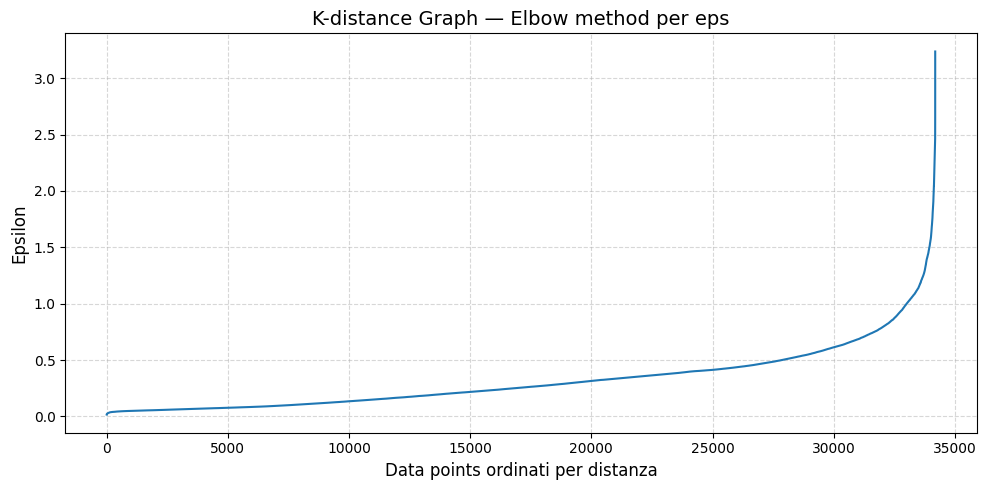

In [41]:
from sklearn.neighbors import NearestNeighbors

# uso solo le feature numeriche (non le binarie tanto non avrebbero effetto sulla distanza)
X_dbscan = transformed_train_scaled[numeric_vars].copy()

# ── 1. K-distance graph per trovare eps ───────────────────────────────
min_samples = 2 * len(numeric_vars)  # m = 2*d = 12
print(f"min_samples: {min_samples}")

neigh = NearestNeighbors(n_neighbors=min_samples)
nbrs = neigh.fit(X_dbscan)
distances, indices = nbrs.kneighbors(X_dbscan)

# Ordina le distanze al K-esimo vicino
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-distance Graph — Elbow method per eps', fontsize=14)
plt.xlabel('Data points ordinati per distanza', fontsize=12)
plt.ylabel('Epsilon', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Dal grafico un eps ragionevole sembra un valore nel range 0.8-1.

Parametri DBSCAN: eps=0.8, min_samples=12

Outlier rilevati: 1048 / 34190 (3.07%)

Distribuzione cluster:
  OUTLIER: 1048 (3.07%)
  Cluster 0: 29420 (86.05%)
  Cluster 1: 2141 (6.26%)
  Cluster 2: 1256 (3.67%)
  Cluster 3: 211 (0.62%)
  Cluster 4: 59 (0.17%)
  Cluster 5: 28 (0.08%)
  Cluster 6: 21 (0.06%)
  Cluster 7: 6 (0.02%)

Dataframe outlier: (1048, 32)


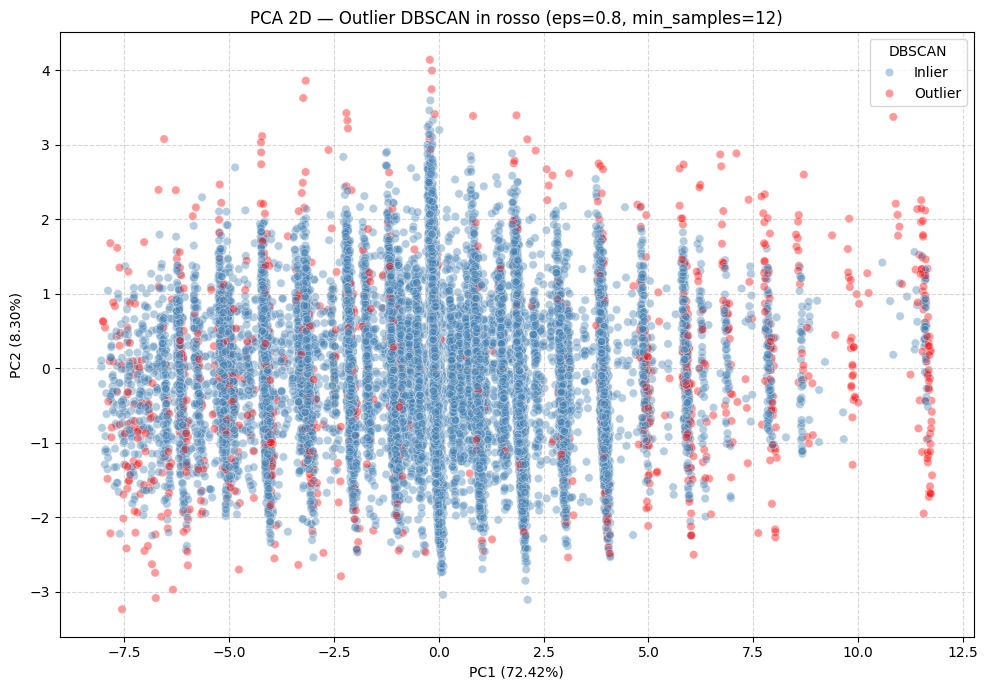

In [42]:

from sklearn.cluster import DBSCAN

eps = 0.8  # valore trovato dall'elbow method
min_samples = 2 * len(numeric_vars)  # 12
print(f"Parametri DBSCAN: eps={eps}, min_samples={min_samples}")

# ── 1. Fit DBSCAN ──────────────────────────────────────────────────────
model = DBSCAN(eps=eps, min_samples=min_samples).fit(X_dbscan)
labels = model.labels_

# ── 2. Identifica outlier (label == -1) ────────────────────────────────
outliers_DBSCAN = (labels == -1).astype(int)
n_outliers = outliers_DBSCAN.sum()
print(f"\nOutlier rilevati: {n_outliers} / {len(X_dbscan)} ({n_outliers/len(X_dbscan)*100:.2f}%)")

# ── 3. Distribuzione cluster ───────────────────────────────────────────
unique_values, counts = np.unique(labels, return_counts=True)
print("\nDistribuzione cluster:")
for value, count in zip(unique_values, counts):
    label_name = "OUTLIER" if value == -1 else f"Cluster {value}"
    print(f"  {label_name}: {count} ({count/len(X_dbscan)*100:.2f}%)")

# ── 4. Salva outlier in dataframe separato ─────────────────────────────
outliers_mask = outliers_DBSCAN == 1
outliers_dbscan_df = data_train[outliers_mask].copy()
outliers_dbscan_df['dbscan_label'] = labels[outliers_mask]
print(f"\nDataframe outlier: {outliers_dbscan_df.shape}")

# ── 5. PCA colorata outlier/inlier ────────────────────────────────────

pca_tmp = PCA(n_components=2, random_state=42)

# Resetta indice per allineare correttamente con outliers_DBSCAN
X_pca_plot = transformed_train_scaled.reset_index(drop=True)

pc = pca_tmp.fit_transform(X_pca_plot)
pc_df_tmp = pd.DataFrame(pc, columns=['PC1', 'PC2'])
pc_df_tmp['is_outlier'] = outliers_DBSCAN
explained = pca_tmp.explained_variance_ratio_ * 100

plt.figure(figsize=(10, 7))
ax = sns.scatterplot(
    x='PC1', y='PC2',
    hue='is_outlier',
    data=pc_df_tmp,
    alpha=0.4,
    palette={0: 'steelblue', 1: 'red'}
)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Inlier', 'Outlier'], title='DBSCAN')
plt.xlabel(f'PC1 ({explained[0]:.2f}%)')
plt.ylabel(f'PC2 ({explained[1]:.2f}%)')
plt.title(f'PCA 2D — Outlier DBSCAN in rosso (eps={eps}, min_samples={min_samples})')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Questa metrica cattura il 3% dei dato come outlier, un valore molto più ragionevole e anche a livello grafico sembrano effettivamente dei punti più lontani, prima di decidere se "fidarmi" di questa metrica visualizzo questi presunti outlier:

In [43]:
#outliers_dbscan_df.head(10)  # per visualizzare a mano primi 10 outlier

inliers_dbscan_df = data_train[~outliers_mask].copy()
cols_to_show = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
print("=== OUTLIER ===")
print(outliers_dbscan_df[cols_to_show].describe().round(3))

print("\n=== INLIER ===")
print(inliers_dbscan_df[cols_to_show].describe().round(3))

=== OUTLIER ===
            age  education-num  capital-gain  capital-loss  hours-per-week
count  1048.000       1048.000      1048.000      1048.000        1048.000
mean     44.498          9.572         3.263         2.185          45.286
std      17.854          3.907         4.182         3.422          29.438
min      17.000          1.000         0.000         0.000           1.000
25%      30.000          7.000         0.000         0.000          20.000
50%      42.000         10.000         0.000         0.000          39.000
75%      59.250         13.000         7.948         7.380          70.000
max      90.000         16.000        11.513         8.380          99.000

=== INLIER ===
             age  education-num  capital-gain  capital-loss  hours-per-week
count  33142.000      33142.000     33142.000     33142.000       33142.000
mean      38.416         10.094         0.638         0.289          40.310
std       13.476          2.508         2.307         1.446      

Visualizzando manualmente gli outlier e confrontando le statistiche dei due dataframe i fattori che influenzano sono principalmente:
- valori di capital-loss/gain
- hours per week

E' difficile valutare se alti valori di capital-loss/gain siano effettivamente outlier nel senso che nell'analisi iniziale avevamo già visto che era logicamente correlato a persone con income >50k e quindi è normale aspettarsi nel mondo finanziario potenziali grandi guadagni o perdite (se pensiamo tipo alla borsa).
Il discorso è analogo per le hours-per-week tuttavia DB-scan ha detectato solamente il 2% del dataset e la visualizzazione grafica sembrava ragionevolte per cui droppo gli outlier.

In [44]:
data_train = data_train.loc[(1 - outliers_DBSCAN).astype(bool)]
print(f"Shape dopo rimozione outlier: {data_train.shape}")

Shape dopo rimozione outlier: (33142, 31)


# Valutazione per tecniche di Feature Transformation

- Considerando che "capital-gain e capital-loss presentavano distribuzioni fortemente asimmetriche a destra con la grande maggioranza dei valori pari a 0 e pochi valori estremi (fino a 99999). È stata applicata la trasformazione log (in realtà già in precedenza per la PCA).

- come Data trasformation è stata applicata una "knowledge-driven" dummification (nelle fasi precedenti)

- scalato i dati tramite Robust scaler perchè SVM è un metodo geometrico (trova l'iperpiano di separazione ottimale usando la metrica della distanza) e pertanto lavora al meglio su uno spazio geometricamente equilibrato (quindi scalato) altrimenti alcune feature andrebbero a dominare le distanze.

In [45]:
# Rimuovo e rinomino le colonne originali non trasformate
data_train = data_train.drop(columns=['capital-gain', 'capital-loss'])
data_test  = data_test.drop(columns=['capital-gain', 'capital-loss'])

data_train = data_train.rename(columns={'capital-gain-log': 'capital-gain', 
                                         'capital-loss-log': 'capital-loss'})
data_test  = data_test.rename(columns={'capital-gain-log': 'capital-gain', 
                                        'capital-loss-log': 'capital-loss'})

print("Colonne finali:", data_train.columns.tolist())
print("Shape train:", data_train.shape)

Colonne finali: ['age', 'fnlwgt', 'education-num', 'hours-per-week', 'income', 'capital-gain', 'capital-loss', 'workclass_Other', 'workclass_Private', 'workclass_Self-employed', 'workclass_Unknown', 'marital-status_Not-married', 'occupation_ Armed-Forces', 'occupation_ Craft-repair', 'occupation_ Exec-managerial', 'occupation_ Farming-fishing', 'occupation_ Handlers-cleaners', 'occupation_ Machine-op-inspct', 'occupation_ Other-service', 'occupation_ Priv-house-serv', 'occupation_ Prof-specialty', 'occupation_ Protective-serv', 'occupation_ Sales', 'occupation_ Tech-support', 'occupation_ Transport-moving', 'occupation_Unknown', 'race_White', 'sex_ Male', 'native-country_United-States']
Shape train: (33142, 29)


In [46]:
from sklearn.preprocessing import RobustScaler

numeric_vars = ['age', 'fnlwgt', 'education-num', 
                'capital-gain', 'capital-loss', 'hours-per-week']

# Salva versione non scalata per confronto
X_train_raw = data_train.drop(columns=['income']).copy()
y_train = data_train['income']
X_test_raw  = data_test.drop(columns=['income']).copy()
y_test  = data_test['income']

# Versione scalata
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()
scaler = RobustScaler()
X_train[numeric_vars] = scaler.fit_transform(X_train[numeric_vars])
X_test[numeric_vars]  = scaler.transform(X_test[numeric_vars])

Valuto la separazione delle classi

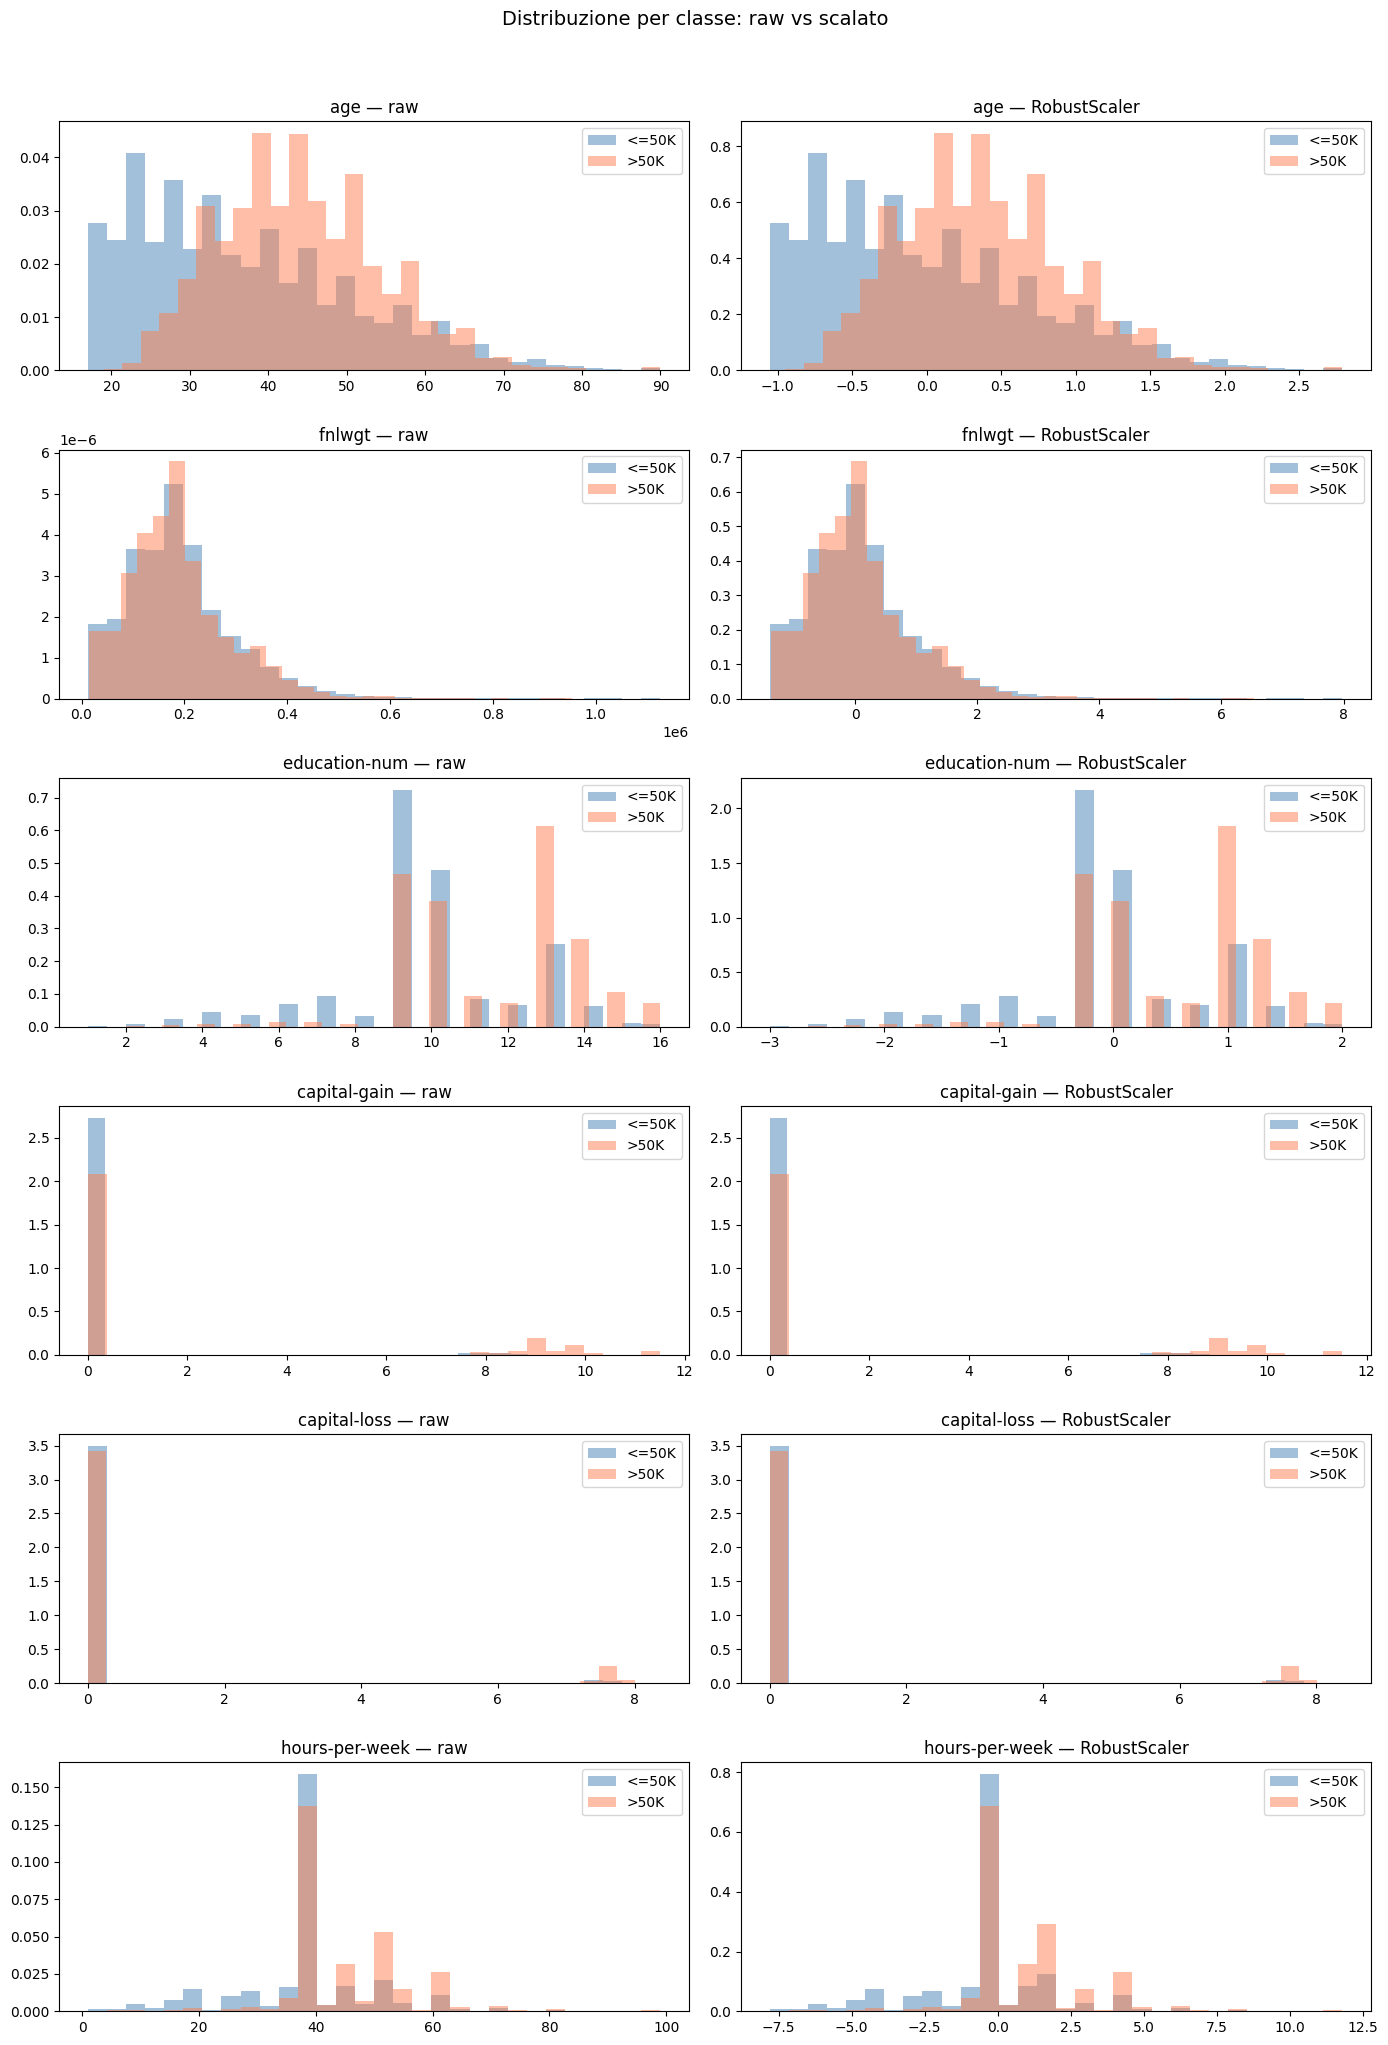

In [47]:
# Plot distribuzione per classe: raw vs scalato
fig, axes = plt.subplots(nrows=len(numeric_vars), ncols=2, figsize=(14, 20))

for i, col in enumerate(numeric_vars):
    for cls, color, label in [(0, 'steelblue', '<=50K'), (1, 'coral', '>50K')]:
        mask = y_train == cls
        # Colonna raw
        axes[i, 0].hist(X_train_raw[col][mask], bins=30, alpha=0.5,
                        color=color, label=label, density=True)
        # Colonna scalata
        axes[i, 1].hist(X_train[col][mask], bins=30, alpha=0.5,
                        color=color, label=label, density=True)
    
    axes[i, 0].set_title(f'{col} — raw')
    axes[i, 0].legend()
    axes[i, 1].set_title(f'{col} — RobustScaler')
    axes[i, 1].legend()

plt.suptitle("Distribuzione per classe: raw vs scalato", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Le classi risultano mediamente separate e come intuito già nelle fasi precedenti l'attributo fnlwgt sembra particolarmente inutile al nostro scopo, motivo per cui valutiamo anche tramite analisi di correlazione se eliminarlo.

Di seguito facciamo una analisi con tutte le variabili, anche quelle dummyficate per valutare se tenerle, visto che il target è binario uso una pointbiserial


In [48]:
from scipy.stats import pointbiserialr

threshold = 0.05  

selected_features = []
correlations = {}

for col in X_train.columns:
    r, p_value = pointbiserialr(y_train, X_train[col])

    correlations[col] = r

    if p_value < 0.05:
        print(f"{col}: r = {r:.4f}, p = {p_value:.4e}")

        if abs(r) >= threshold:
            selected_features.append(col)

corr_df = pd.DataFrame.from_dict(
    correlations,
    orient='index',
    columns=['correlation']
).sort_values(by='correlation', key=np.abs, ascending=False)

print("\nFeature selezionate:")
print(selected_features)

print(f"\nNumero feature originali: {X_train.shape[1]}")
print(f"Numero feature selezionate: {len(selected_features)}")

X_train= X_train[selected_features]
X_test= X_test[selected_features]

age: r = 0.2341, p = 0.0000e+00
education-num: r = 0.3326, p = 0.0000e+00
hours-per-week: r = 0.2353, p = 0.0000e+00
capital-gain: r = 0.2944, p = 0.0000e+00
capital-loss: r = 0.1403, p = 2.5116e-145
workclass_Private: r = -0.0755, p = 3.9585e-43
workclass_Self-employed: r = 0.0977, p = 4.0462e-71
workclass_Unknown: r = -0.0845, p = 1.5743e-53
marital-status_Not-married: r = -0.4454, p = 0.0000e+00
occupation_ Exec-managerial: r = 0.2065, p = 6.7062e-316
occupation_ Farming-fishing: r = -0.0534, p = 2.4719e-22
occupation_ Handlers-cleaners: r = -0.0834, p = 2.8923e-52
occupation_ Machine-op-inspct: r = -0.0694, p = 1.2446e-36
occupation_ Other-service: r = -0.1493, p = 2.0118e-164
occupation_ Priv-house-serv: r = -0.0367, p = 2.2842e-11
occupation_ Prof-specialty: r = 0.1883, p = 3.3799e-262
occupation_ Protective-serv: r = 0.0239, p = 1.3711e-05
occupation_ Sales: r = 0.0183, p = 8.6853e-04
occupation_ Tech-support: r = 0.0233, p = 2.2319e-05
occupation_ Transport-moving: r = -0.0181,

Come ci si aspettava feature come la fnlwgt sono state scartate.

# SVM 

Applico quindi il modello lineare SVM dopo le trasformazioni e lo valuto secondo le metriche standard di precisione, recall e f1.

In [49]:
from sklearn.svm import LinearSVC
from sklearn.metrics import  classification_report

svm = LinearSVC(max_iter=2000, random_state=0)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90     11148
        >50K       0.71      0.57      0.64      3506

    accuracy                           0.84     14654
   macro avg       0.79      0.75      0.77     14654
weighted avg       0.84      0.84      0.84     14654



Il modello ottiene globalmente dei buoni risultati ma bisogna considerare:
- il modello tende a privilegiare la classe dominante, classificando erroneamente una quota significativa di individui appartenenti alla classe >50K come <=50K (57% di recall)

Questo è sicuramente influenzato da un dataset sbilanciato come è stato visto all'inizio.

Per questo motivo provo ad applicare la tecnica SMOTE:
- è una tecnica di oversampling della classe minoritaria, in sostanza vengono sinteticamente creati nuovi sample, l'idea è quella di prendere per ogni sample minoritario i kNN vicini e creane uno nuovo che sia le media di questi, una sorta di interpolazione allo scopo di bilanciare il dataset.

In [50]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

#Stampo le distribuzioni per controllare che stia facendo il bilanciamento
print("Distribuzione originale y_train:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nDistribuzione dopo SMOTE:")
print(y_train_balanced.value_counts())

#retriano
svm_balanced = LinearSVC(max_iter=2000, random_state=0)
svm_balanced.fit(X_train_balanced, y_train_balanced)

#Predizione sul test originale (non bilanciato)
y_pred_balanced = svm_balanced.predict(X_test)

print("\nClassification Report dopo SMOTE:")
print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=['<=50K', '>50K']
    )
)

Distribuzione originale y_train:
income
0    25303
1     7839
Name: count, dtype: int64

Distribuzione dopo SMOTE:
income
1    25303
0    25303
Name: count, dtype: int64

Classification Report dopo SMOTE:
              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.85     11148
        >50K       0.55      0.85      0.67      3506

    accuracy                           0.80     14654
   macro avg       0.75      0.82      0.76     14654
weighted avg       0.85      0.80      0.81     14654



Dopo il bilanciamento, il modello SVM mostra una significativa variazione del comportamento classificativo:

-  il recall della classe minoritaria aumenta da 0.57 a 0.86, indicando una maggiore capacità di identificare correttamente gli individui con reddito >50K. (che era l'attuale obiettivo)

-  Tuttavia in modo parallelo la precision della stessa classe diminuisce da 0.71 a 0.55, evidenziando un incremento dei falsi positivi ed la capacità di classificazione della classe <=50k è leggermente peggiorata.


In conclusione entrambe le versione presentano dei pro e dei contro, ma in presenza di dataset sbilanciati una tecnica come SMOTE risulta preferibile quando l’obiettivo è migliorare il riconoscimento della classe minoritaria.